# Galapagos Sharks HMM Analysis Workflow (reorganized + output-managed)

This notebook follows the revised analysis logic:

1. Treat **sensor detachment as QC/artifact removal**, not as a biological state.
2. Fit **both 2-state and 3-state HMMs** on cleaned data.
3. Use the **2-state model as the main biological workflow by default** for interpretability and cross-shark comparability.
4. Keep **3-state results as secondary model-comparison evidence**.
5. Compute **day/night transitions only on true consecutive 5-minute steps**.
6. Treat **light as a descriptive diel-context variable** unless you later fit a true covariate-dependent HMM.

All figures are saved into **one output folder**, and all text summaries are appended to **one log file in the same folder**.

## 0. User inputs

Before running:

- Put the two raw CSV files in the same folder as this notebook, or update the paths below.
- The notebook will create an output folder called `revised_hmm_outputs`.
- All `.png` figures and the main text log will be saved there automatically.

In [1]:
# ============================
# USER INPUTS
# ============================

SHARK1_PATH = "20240604-203035-test 89.csv"
SHARK2_PATH = "20240605-214932-CC-07-90.csv"

WINDOW_MINUTES = 5
ROLL_N = 200

# Candidate detachment rule
DETACH_DEPTH_THRESH = 5.0
DETACH_ODBA_THRESH = 2.0

# Optional buffer before a terminal detachment block
DETACH_BUFFER_WINDOWS = 0

# If an isolated artifact-like point appears right at the beginning,
# allow removal only within this many windows from start
STARTUP_ARTIFACT_MAX_INDEX = 3

# HMM settings
RANDOM_SEEDS = [11, 22, 33, 44, 55, 66, 77, 88, 99, 490]

# Output settings
OUTPUT_DIR_NAME = "revised_hmm_outputs"
RESET_OUTPUT_DIR = True

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import jensenshannon
from hmmlearn.hmm import GaussianHMM
from IPython.display import display

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = False
plt.rcParams["savefig.facecolor"] = "white"

OUTPUT_DIR = Path(OUTPUT_DIR_NAME)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if RESET_OUTPUT_DIR:
    for p in OUTPUT_DIR.glob("*"):
        if p.is_file():
            p.unlink()

LOG_PATH = OUTPUT_DIR / "analysis_log.txt"

def lp(*args, sep=" ", end="\n"):
    text = sep.join(str(a) for a in args)
    print(text, end=end)
    with open(LOG_PATH, "a", encoding="utf-8") as f:
        f.write(text + end)

def savefig(name, fig=None, dpi=250):
    fig = fig if fig is not None else plt.gcf()
    path = OUTPUT_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    lp(f"[saved figure] {path}")
    return path

def save_table(df, name, index=False):
    path = OUTPUT_DIR / name
    df.to_csv(path, index=index)
    lp(f"[saved table] {path}")
    return path

lp("=" * 80)
lp("REVISED SHARK HMM ANALYSIS")
lp("=" * 80)
lp(f"Output directory: {OUTPUT_DIR.resolve()}")
lp(f"Log file: {LOG_PATH.resolve()}")

REVISED SHARK HMM ANALYSIS
Output directory: /Users/keiserj/Desktop/uoft year 4/STA490/newdata/revised_hmm_outputs
Log file: /Users/keiserj/Desktop/uoft year 4/STA490/newdata/revised_hmm_outputs/analysis_log.txt


## 1. Load and clean raw data

In [3]:
def clean_columns(df):
    out = df.copy()
    out.columns = [c.strip() for c in out.columns]
    return out

def rename_shark1(df):
    rename_map = {}
    for c in df.columns:
        if "Accelerometer X" in c: rename_map[c] = "acc_x"
        elif "Accelerometer Y" in c: rename_map[c] = "acc_y"
        elif "Accelerometer Z" in c: rename_map[c] = "acc_z"
        elif "Gyroscope X" in c: rename_map[c] = "gyro_x"
        elif "Gyroscope Y" in c: rename_map[c] = "gyro_y"
        elif "Gyroscope Z" in c: rename_map[c] = "gyro_z"
        elif "Magnetometer X" in c: rename_map[c] = "mag_x"
        elif "Magnetometer Y" in c: rename_map[c] = "mag_y"
        elif "Magnetometer Z" in c: rename_map[c] = "mag_z"
        elif "Temperature (imu)" in c: rename_map[c] = "temp_imu"
        elif "Depth (100bar) 1" in c: rename_map[c] = "depth_m"
        elif "Depth (100bar) 2" in c: rename_map[c] = "depth_temp"
        elif "Light intensity 1" in c: rename_map[c] = "light_1"
        elif "Light intensity 2" in c: rename_map[c] = "light_2"
        elif c == "BATT [V]": rename_map[c] = "batt_v"
        elif c == "BATT [mA]": rename_map[c] = "batt_ma"
        elif c == "BATT [mAh]": rename_map[c] = "batt_mah"
    return df.rename(columns=rename_map)

def rename_shark2(df):
    rename_map = {}
    for c in df.columns:
        if "Accelerometer X" in c: rename_map[c] = "acc_x"
        elif "Accelerometer Y" in c: rename_map[c] = "acc_y"
        elif "Accelerometer Z" in c: rename_map[c] = "acc_z"
        elif "Gyroscope X" in c: rename_map[c] = "gyro_x"
        elif "Gyroscope Y" in c: rename_map[c] = "gyro_y"
        elif "Gyroscope Z" in c: rename_map[c] = "gyro_z"
        elif "Magnetometer X" in c: rename_map[c] = "mag_x"
        elif "Magnetometer Y" in c: rename_map[c] = "mag_y"
        elif "Magnetometer Z" in c: rename_map[c] = "mag_z"
        elif "Temperature (imu)" in c: rename_map[c] = "temp_imu"
        elif "Depth (200bar) 1" in c: rename_map[c] = "depth_m"
        elif "Depth (200bar) 2" in c: rename_map[c] = "depth_temp"
        elif "Light intensity 1" in c: rename_map[c] = "light_1"
        elif "Light intensity 2" in c: rename_map[c] = "light_2"
        elif c == "BATT [V]": rename_map[c] = "batt_v"
        elif c == "BATT [mA]": rename_map[c] = "batt_ma"
        elif c == "BATT [mAh]": rename_map[c] = "batt_mah"
    return df.rename(columns=rename_map)

def parse_local_datetime(df):
    out = df.copy()
    date_local_col = [c for c in out.columns if "Date (local)" in c][0]
    time_local_col = [c for c in out.columns if "Time (local)" in c][0]
    out["datetime_local"] = pd.to_datetime(
        out[date_local_col].astype(str) + " " + out[time_local_col].astype(str),
        format="%d.%m.%Y %H:%M:%S.%f",
        errors="coerce"
    )
    return out

shark1 = pd.read_csv(SHARK1_PATH, encoding="latin1")
shark2 = pd.read_csv(SHARK2_PATH, encoding="latin1")

shark1 = parse_local_datetime(rename_shark1(clean_columns(shark1)))
shark2 = parse_local_datetime(rename_shark2(clean_columns(shark2)))

lp("Shark 1 shape:", shark1.shape)
lp("Shark 2 shape:", shark2.shape)
lp("Shark 1 time range:", shark1["datetime_local"].min(), "to", shark1["datetime_local"].max())
lp("Shark 2 time range:", shark2["datetime_local"].min(), "to", shark2["datetime_local"].max())

Shark 1 shape: (2264202, 29)
Shark 2 shape: (2171586, 37)
Shark 1 time range: 2024-06-03 06:58:37 to 2024-06-04 14:25:27.050000
Shark 2 time range: 2024-06-04 07:55:00 to 2024-06-05 14:04:39.250000


## 2. Compute ODBA and build 5-minute windows

In [4]:
def compute_odba(df, roll_n=200):
    out = df.copy()
    for col in ["acc_x", "acc_y", "acc_z"]:
        out[f"{col}_static"] = out[col].rolling(window=roll_n, center=True, min_periods=1).mean()
        out[f"{col}_dyn"] = out[col] - out[f"{col}_static"]
    out["odba"] = out["acc_x_dyn"].abs() + out["acc_y_dyn"].abs() + out["acc_z_dyn"].abs()
    return out

def build_windowed_hmm_df(df, shark_name, window_minutes=5):
    out = df.copy()
    out["shark_id"] = shark_name

    for col in ["depth_m", "depth_temp", "light_1", "light_2", "odba"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=["datetime_local", "depth_m", "odba"]).copy()
    out = out.sort_values("datetime_local").reset_index(drop=True)
    out["time_window"] = out["datetime_local"].dt.floor(f"{window_minutes}min")

    win = (
        out.groupby("time_window", as_index=False)
        .agg(
            mean_depth=("depth_m", "mean"),
            mean_odba=("odba", "mean"),
            mean_temp=("depth_temp", "mean"),
            mean_light_1=("light_1", "mean"),
            mean_light_2=("light_2", "mean"),
            n_in_window=("depth_m", "size")
        )
        .sort_values("time_window")
        .reset_index(drop=True)
    )

    win["log_odba"] = np.log1p(win["mean_odba"])
    win["hour"] = win["time_window"].dt.hour
    win["is_day"] = win["hour"].between(6, 17)
    win["period"] = np.where(win["is_day"], "Day (06-18)", "Night (18-06)")
    win["shark_id"] = shark_name

    return win

shark1 = compute_odba(shark1, roll_n=ROLL_N)
shark2 = compute_odba(shark2, roll_n=ROLL_N)

shark1_win_raw = build_windowed_hmm_df(shark1, "Shark 1", WINDOW_MINUTES)
shark2_win_raw = build_windowed_hmm_df(shark2, "Shark 2", WINDOW_MINUTES)

lp("\nRaw window counts:")
lp("  Shark 1:", len(shark1_win_raw))
lp("  Shark 2:", len(shark2_win_raw))


Raw window counts:
  Shark 1: 379
  Shark 2: 362


## 3. Identify candidate sensor detachment windows

This is treated as a **QC step**, not a state model.

### Working rule
A window is a candidate artifact if it is simultaneously:
- very **shallow**
- unusually **high ODBA**

Then we preferentially remove the **terminal candidate run**, because that is most consistent with tag/sensor detachment.

In [5]:
def flag_candidate_detachment(df, depth_thresh=5.0, odba_thresh=2.0):
    out = df.copy()
    out["candidate_detach"] = (
        (out["mean_depth"] < depth_thresh) &
        (out["mean_odba"] > odba_thresh)
    )
    return out

def contiguous_runs(mask):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return []
    runs = []
    start = idx[0]
    prev = idx[0]
    for i in idx[1:]:
        if i == prev + 1:
            prev = i
        else:
            runs.append((start, prev))
            start = i
            prev = i
    runs.append((start, prev))
    return runs

def choose_detachment_windows(df, buffer_windows=0, startup_artifact_max_index=3):
    out = df.copy()
    runs = contiguous_runs(out["candidate_detach"].to_numpy())
    remove_idx = set()

    # Prefer the terminal run if present
    if runs:
        terminal_runs = [r for r in runs if r[1] >= len(out) - 3]
        if terminal_runs:
            start, end = terminal_runs[-1]
            start = max(0, start - buffer_windows)
            remove_idx.update(range(start, end + 1))

    # Optionally drop isolated early startup artifacts
    for start, end in runs:
        if end <= startup_artifact_max_index:
            remove_idx.update(range(start, end + 1))

    out["remove_detach"] = False
    if remove_idx:
        out.loc[sorted(remove_idx), "remove_detach"] = True

    return out, runs

shark1_win_raw = flag_candidate_detachment(
    shark1_win_raw,
    depth_thresh=DETACH_DEPTH_THRESH,
    odba_thresh=DETACH_ODBA_THRESH
)
shark2_win_raw = flag_candidate_detachment(
    shark2_win_raw,
    depth_thresh=DETACH_DEPTH_THRESH,
    odba_thresh=DETACH_ODBA_THRESH
)

shark1_win_raw, runs1 = choose_detachment_windows(
    shark1_win_raw,
    buffer_windows=DETACH_BUFFER_WINDOWS,
    startup_artifact_max_index=STARTUP_ARTIFACT_MAX_INDEX
)
shark2_win_raw, runs2 = choose_detachment_windows(
    shark2_win_raw,
    buffer_windows=DETACH_BUFFER_WINDOWS,
    startup_artifact_max_index=STARTUP_ARTIFACT_MAX_INDEX
)

lp("\nSensor detachment identification")
lp("-" * 80)
lp(f"Criteria: depth < {DETACH_DEPTH_THRESH} m AND ODBA > {DETACH_ODBA_THRESH}")
lp("Candidate runs (Shark 1):", runs1)
lp("Candidate runs (Shark 2):", runs2)

for name, df in [("Shark 1", shark1_win_raw), ("Shark 2", shark2_win_raw)]:
    lp(f"\n{name}")
    lp("  Candidate windows:", int(df["candidate_detach"].sum()))
    lp("  Removed windows:", int(df["remove_detach"].sum()))
    if df["remove_detach"].any():
        det = df.loc[df["remove_detach"]].copy()
        lp("  Removal interval:", det["time_window"].min(), "to", det["time_window"].max())
        lp("  Mean removed depth:", round(det["mean_depth"].mean(), 3))
        lp("  Mean removed ODBA:", round(det["mean_odba"].mean(), 3))
        save_table(det, f"{name.lower().replace(' ', '_')}_removed_detachment_windows.csv", index=False)


Sensor detachment identification
--------------------------------------------------------------------------------
Criteria: depth < 5.0 m AND ODBA > 2.0
Candidate runs (Shark 1): [(1, 1), (318, 378)]
Candidate runs (Shark 2): [(1, 1), (289, 361)]

Shark 1
  Candidate windows: 62
  Removed windows: 62
  Removal interval: 2024-06-03 07:00:00 to 2024-06-04 14:25:00
  Mean removed depth: 1.619
  Mean removed ODBA: 4.41
[saved table] revised_hmm_outputs/shark_1_removed_detachment_windows.csv

Shark 2
  Candidate windows: 74
  Removed windows: 74
  Removal interval: 2024-06-04 08:00:00 to 2024-06-05 14:00:00
  Mean removed depth: 0.632
  Mean removed ODBA: 4.537
[saved table] revised_hmm_outputs/shark_2_removed_detachment_windows.csv


[saved figure] revised_hmm_outputs/fig01_detachment_space.png


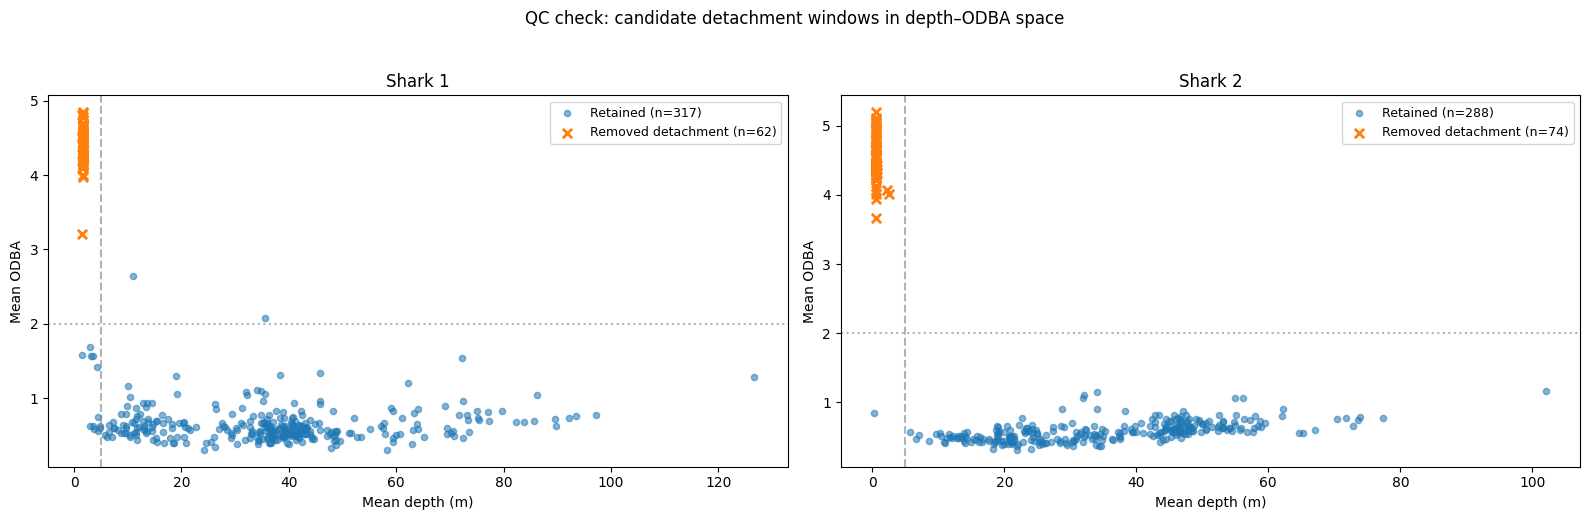

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df, name) in zip(axes, [(shark1_win_raw, "Shark 1"), (shark2_win_raw, "Shark 2")]):
    kept = df.loc[~df["remove_detach"]]
    rem = df.loc[df["remove_detach"]]

    ax.scatter(kept["mean_depth"], kept["mean_odba"], s=20, alpha=0.55, label=f"Retained (n={len(kept)})")
    ax.scatter(rem["mean_depth"], rem["mean_odba"], s=45, marker="x", linewidth=2, label=f"Removed detachment (n={len(rem)})")
    ax.axvline(DETACH_DEPTH_THRESH, color="gray", linestyle="--", alpha=0.6)
    ax.axhline(DETACH_ODBA_THRESH, color="gray", linestyle=":", alpha=0.6)
    ax.set_title(name)
    ax.set_xlabel("Mean depth (m)")
    ax.set_ylabel("Mean ODBA")
    ax.legend(fontsize=9)

plt.suptitle("QC check: candidate detachment windows in depth–ODBA space", y=1.03)
plt.tight_layout()
savefig("fig01_detachment_space.png")
plt.show()

[saved figure] revised_hmm_outputs/fig02_detachment_timeseries.png


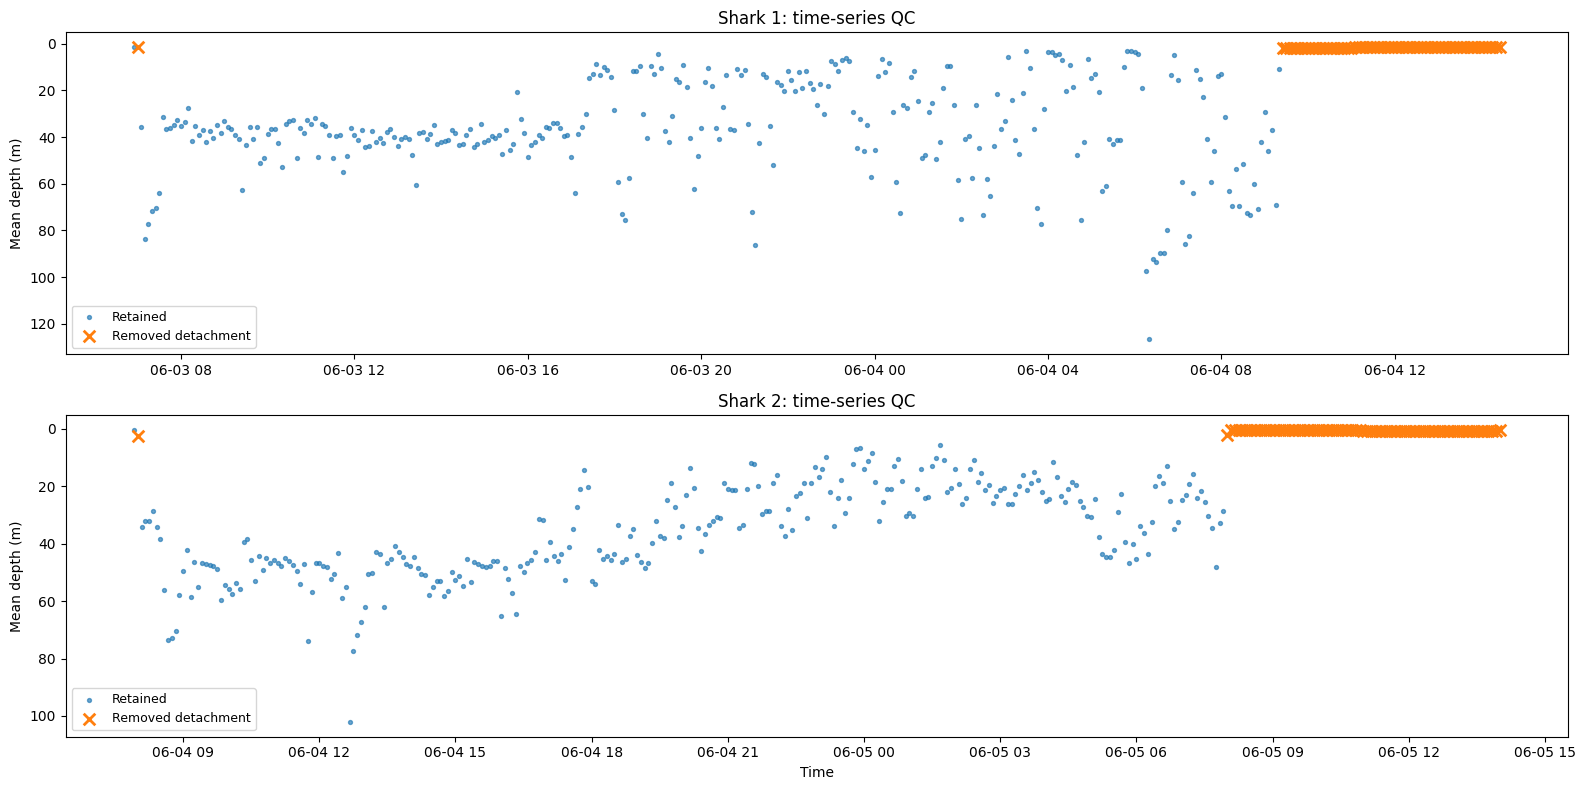

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, (df, name) in zip(axes, [(shark1_win_raw, "Shark 1"), (shark2_win_raw, "Shark 2")]):
    kept = df.loc[~df["remove_detach"]]
    rem = df.loc[df["remove_detach"]]
    ax.scatter(kept["time_window"], kept["mean_depth"], s=8, alpha=0.65, label="Retained")
    ax.scatter(rem["time_window"], rem["mean_depth"], s=70, marker="x", linewidth=2, label="Removed detachment")
    ax.invert_yaxis()
    ax.set_ylabel("Mean depth (m)")
    ax.set_title(f"{name}: time-series QC")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
savefig("fig02_detachment_timeseries.png")
plt.show()

## 4. Create cleaned datasets

In [8]:
shark1_win = shark1_win_raw.loc[~shark1_win_raw["remove_detach"]].copy().reset_index(drop=True)
shark2_win = shark2_win_raw.loc[~shark2_win_raw["remove_detach"]].copy().reset_index(drop=True)

lp("\nClean window counts:")
lp("  Shark 1:", len(shark1_win))
lp("  Shark 2:", len(shark2_win))


Clean window counts:
  Shark 1: 317
  Shark 2: 288


## 5. Fit 2-state and 3-state HMMs on cleaned data

Interpretation rule:

- Fit **both** 2-state and 3-state models.
- Report the model comparison honestly.
- Keep the **2-state model as the default downstream workflow** if you want a cleaner biological comparison.
- If the 3-state model still wins strongly by AIC/BIC, describe it as **secondary evidence of additional substructure**, not as something to ignore.

In [9]:
def standardize_for_hmm(df, cols):
    out = df.copy()
    for col in cols:
        mu = out[col].mean()
        sd = out[col].std(ddof=0)
        out[f"{col}_z"] = (out[col] - mu) / sd
    return out

def add_small_jitter(df, cols, seed=490, scale=1e-6):
    out = df.copy()
    rng = np.random.default_rng(seed)
    for col in cols:
        out[f"{col}_jit"] = out[col] + rng.normal(0, scale, len(out))
    return out

def fit_best_hmm(X, n_states, seeds):
    best_model, best_score = None, -np.inf
    for seed in seeds:
        model = GaussianHMM(
            n_components=n_states,
            covariance_type="diag",
            n_iter=500,
            random_state=seed
        )
        model.fit(X)
        score = model.score(X)
        if score > best_score:
            best_score = score
            best_model = model
    return best_model, best_score

def hmm_aic_bic(loglik, n_states, n_features, n_obs):
    n_params = (
        (n_states - 1) +            # initial probabilities
        n_states * (n_states - 1) + # transition matrix
        n_states * n_features +     # means
        n_states * n_features       # diagonal variances
    )
    aic = -2 * loglik + 2 * n_params
    bic = -2 * loglik + np.log(n_obs) * n_params
    return aic, bic

def decode_hmm(df, model, feature_cols):
    out = df.copy()
    X = out[feature_cols].to_numpy()
    out["state"] = model.predict(X) + 1
    return out

def hmm_summary_table(df_results):
    tab = (
        df_results.groupby("state", as_index=False)
        .agg(
            mean_depth=("mean_depth", "mean"),
            sd_depth=("mean_depth", "std"),
            mean_odba=("mean_odba", "mean"),
            sd_odba=("mean_odba", "std"),
            mean_temp=("mean_temp", "mean"),
            mean_light_1=("mean_light_1", "mean"),
            n=("state", "size")
        )
    )
    tab["prop"] = tab["n"] / tab["n"].sum()
    return tab

for dname in ["shark1_win", "shark2_win"]:
    locals()[dname] = standardize_for_hmm(locals()[dname], ["mean_depth", "log_odba"])
    locals()[dname] = add_small_jitter(locals()[dname], ["mean_depth_z", "log_odba_z"], seed=490)

X1 = shark1_win[["mean_depth_z_jit", "log_odba_z_jit"]].to_numpy()
X2 = shark2_win[["mean_depth_z_jit", "log_odba_z_jit"]].to_numpy()

model_sh1_2, ll_sh1_2 = fit_best_hmm(X1, 2, RANDOM_SEEDS)
model_sh1_3, ll_sh1_3 = fit_best_hmm(X1, 3, RANDOM_SEEDS)
model_sh2_2, ll_sh2_2 = fit_best_hmm(X2, 2, RANDOM_SEEDS)
model_sh2_3, ll_sh2_3 = fit_best_hmm(X2, 3, RANDOM_SEEDS)

aic_sh1_2, bic_sh1_2 = hmm_aic_bic(ll_sh1_2, 2, 2, len(X1))
aic_sh1_3, bic_sh1_3 = hmm_aic_bic(ll_sh1_3, 3, 2, len(X1))
aic_sh2_2, bic_sh2_2 = hmm_aic_bic(ll_sh2_2, 2, 2, len(X2))
aic_sh2_3, bic_sh2_3 = hmm_aic_bic(ll_sh2_3, 3, 2, len(X2))

model_compare = pd.DataFrame({
    "shark": ["Shark 1", "Shark 1", "Shark 2", "Shark 2"],
    "model": ["2-state", "3-state", "2-state", "3-state"],
    "logLik": [ll_sh1_2, ll_sh1_3, ll_sh2_2, ll_sh2_3],
    "AIC": [aic_sh1_2, aic_sh1_3, aic_sh2_2, aic_sh2_3],
    "BIC": [bic_sh1_2, bic_sh1_3, bic_sh2_2, bic_sh2_3]
})
display(model_compare)
save_table(model_compare, "table01_model_comparison.csv", index=False)

lp("\nModel comparison")
lp("-" * 80)
for _, row in model_compare.iterrows():
    lp(f"{row['shark']}, {row['model']}: logLik={row['logLik']:.3f}, AIC={row['AIC']:.3f}, BIC={row['BIC']:.3f}")

,shark,model,logLik,AIC,BIC
0,Shark 1,2-state,-782.240771,1586.481541,1627.829461
1,Shark 1,3-state,-674.980592,1389.961185,1465.139220
2,Shark 2,2-state,-595.937244,1213.874488,1254.167053
3,Shark 2,3-state,-526.962799,1093.925597,1167.184807


[saved table] revised_hmm_outputs/table01_model_comparison.csv

Model comparison
--------------------------------------------------------------------------------
Shark 1, 2-state: logLik=-782.241, AIC=1586.482, BIC=1627.829
Shark 1, 3-state: logLik=-674.981, AIC=1389.961, BIC=1465.139
Shark 2, 2-state: logLik=-595.937, AIC=1213.874, BIC=1254.167
Shark 2, 3-state: logLik=-526.963, AIC=1093.926, BIC=1167.185


[saved figure] revised_hmm_outputs/fig03_model_comparison_aic_bic.png


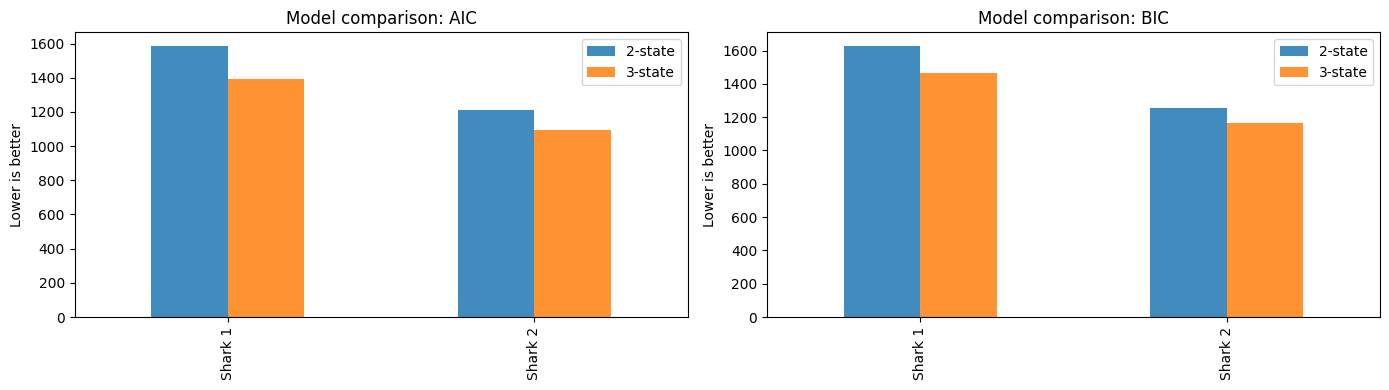

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

aic_plot = pd.DataFrame({
    "Shark 1": [aic_sh1_2, aic_sh1_3],
    "Shark 2": [aic_sh2_2, aic_sh2_3]
}, index=["2-state", "3-state"]).T

bic_plot = pd.DataFrame({
    "Shark 1": [bic_sh1_2, bic_sh1_3],
    "Shark 2": [bic_sh2_2, bic_sh2_3]
}, index=["2-state", "3-state"]).T

aic_plot.plot(kind="bar", ax=axes[0], alpha=0.85)
bic_plot.plot(kind="bar", ax=axes[1], alpha=0.85)

axes[0].set_title("Model comparison: AIC")
axes[1].set_title("Model comparison: BIC")
axes[0].set_ylabel("Lower is better")
axes[1].set_ylabel("Lower is better")

plt.tight_layout()
savefig("fig03_model_comparison_aic_bic.png")
plt.show()

## 6. Inspect state structure before deciding what to use as the primary model

This section is there to keep the logic honest.

- If the 3-state model clearly improves fit **and** reveals a stable extra biological pattern, you can discuss it.
- If the 3-state model mainly splits an existing behavior into sub-regimes, you can still keep the **2-state model** as the main interpretation for comparability.

In [11]:
shark1_res_2 = decode_hmm(shark1_win, model_sh1_2, ["mean_depth_z_jit", "log_odba_z_jit"])
shark1_res_3 = decode_hmm(shark1_win, model_sh1_3, ["mean_depth_z_jit", "log_odba_z_jit"])
shark2_res_2 = decode_hmm(shark2_win, model_sh2_2, ["mean_depth_z_jit", "log_odba_z_jit"])
shark2_res_3 = decode_hmm(shark2_win, model_sh2_3, ["mean_depth_z_jit", "log_odba_z_jit"])

summary_sh1_2 = hmm_summary_table(shark1_res_2)
summary_sh1_3 = hmm_summary_table(shark1_res_3)
summary_sh2_2 = hmm_summary_table(shark2_res_2)
summary_sh2_3 = hmm_summary_table(shark2_res_3)

display(summary_sh1_2)
display(summary_sh1_3)
display(summary_sh2_2)
display(summary_sh2_3)

save_table(summary_sh1_2, "table02_shark1_2state_summary.csv", index=False)
save_table(summary_sh1_3, "table03_shark1_3state_summary.csv", index=False)
save_table(summary_sh2_2, "table04_shark2_2state_summary.csv", index=False)
save_table(summary_sh2_3, "table05_shark2_3state_summary.csv", index=False)

,state,mean_depth,sd_depth,mean_odba,sd_odba,mean_temp,mean_light_1,n,prop
0,1,34.183064,16.188400,0.563936,0.103633,23.275858,15906.593718,250,0.788644
1,2,44.989888,30.655645,0.968865,0.380608,22.284450,9784.020842,67,0.211356


,state,mean_depth,sd_depth,mean_odba,sd_odba,mean_temp,mean_light_1,n,prop
0,1,13.225220,5.596696,0.617786,0.147520,23.891643,6271.224919,84,0.264984
1,2,53.199941,24.509702,0.822822,0.387753,21.976524,4771.637365,92,0.290221
2,3,39.395571,5.237375,0.555349,0.096827,23.285704,26002.867342,141,0.444795


,state,mean_depth,sd_depth,mean_odba,sd_odba,mean_temp,mean_light_1,n,prop
0,1,22.699497,7.863505,0.488968,0.078349,23.573238,3176.257719,139,0.482639
1,2,47.880589,11.006201,0.674424,0.128653,22.927607,16353.204691,149,0.517361


,state,mean_depth,sd_depth,mean_odba,sd_odba,mean_temp,mean_light_1,n,prop
0,1,22.979991,8.021115,0.490367,0.078178,23.558847,3109.161930,142,0.493056
1,2,47.362090,6.559245,0.634141,0.078316,23.017985,17946.687037,117,0.406250
2,3,51.203951,20.822115,0.849282,0.148467,22.566655,11615.998092,29,0.100694


[saved table] revised_hmm_outputs/table02_shark1_2state_summary.csv
[saved table] revised_hmm_outputs/table03_shark1_3state_summary.csv
[saved table] revised_hmm_outputs/table04_shark2_2state_summary.csv
[saved table] revised_hmm_outputs/table05_shark2_3state_summary.csv


PosixPath('revised_hmm_outputs/table05_shark2_3state_summary.csv')

[saved figure] revised_hmm_outputs/fig04_state_structure_2state_3state.png


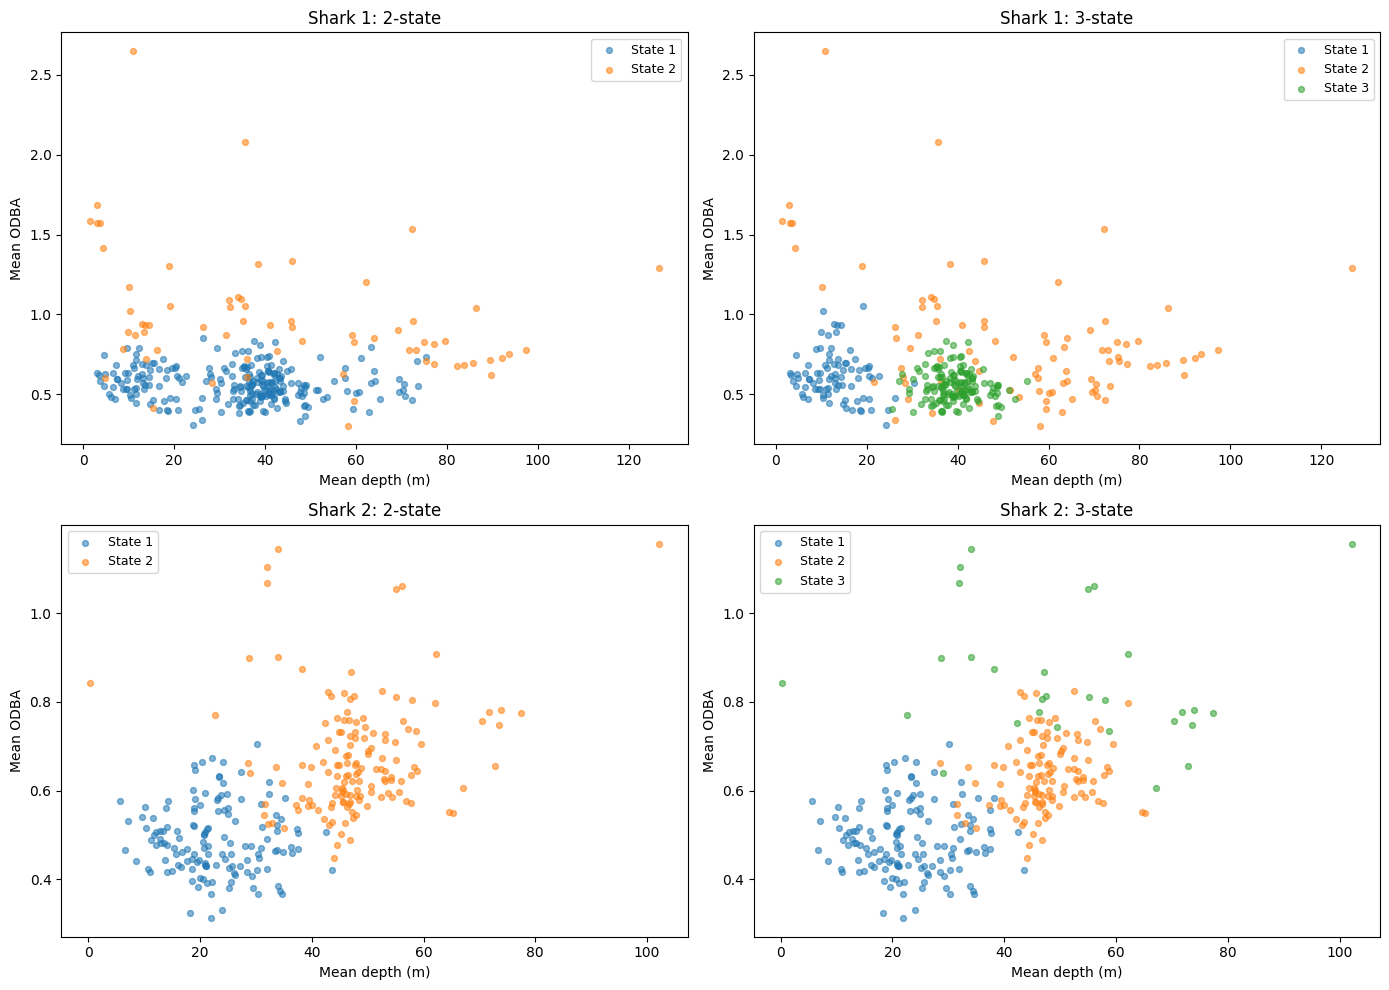

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (df, title) in zip(
    axes.ravel(),
    [
        (shark1_res_2, "Shark 1: 2-state"),
        (shark1_res_3, "Shark 1: 3-state"),
        (shark2_res_2, "Shark 2: 2-state"),
        (shark2_res_3, "Shark 2: 3-state"),
    ]
):
    for state, sub in df.groupby("state"):
        ax.scatter(sub["mean_depth"], sub["mean_odba"], s=18, alpha=0.55, label=f"State {state}")
    ax.set_title(title)
    ax.set_xlabel("Mean depth (m)")
    ax.set_ylabel("Mean ODBA")
    ax.legend(fontsize=9)

plt.tight_layout()
savefig("fig04_state_structure_2state_3state.png")
plt.show()

## 7. Choose the primary model

This notebook uses the **2-state model as the main downstream workflow by default**.

That does **not** mean it is always statistically optimal. It means:
- it is easier to interpret biologically,
- it is easier to compare across sharks,
- and it avoids overselling weak extra substructure.

If you later decide to make the 3-state model primary, you can switch the objects in the next cell.

In [13]:
PRIMARY_SH1 = shark1_res_2.copy()
PRIMARY_SH2 = shark2_res_2.copy()
PRIMARY_N_STATES = 2
lp("\nPrimary model used downstream: 2-state HMM")


Primary model used downstream: 2-state HMM


## 8. Label the primary states conservatively

Use conservative biological labels:

- **Cruising / Routine Swimming**
- **Deep Diving / Active Diving**

Avoid claiming **foraging** unless you have stronger external evidence.

In [14]:
def label_2state_behavior(df):
    tab = hmm_summary_table(df).sort_values("mean_depth").reset_index(drop=True)
    shallow_state = int(tab.loc[0, "state"])
    deep_state = int(tab.loc[1, "state"])

    mapping = {
        shallow_state: "Cruising / Routine Swimming",
        deep_state: "Deep Diving / Active Diving"
    }

    out = df.copy()
    out["bio"] = out["state"].map(mapping)
    return out, mapping

PRIMARY_SH1, MAP_SH1 = label_2state_behavior(PRIMARY_SH1)
PRIMARY_SH2, MAP_SH2 = label_2state_behavior(PRIMARY_SH2)

BIO_ORDER = ["Cruising / Routine Swimming", "Deep Diving / Active Diving"]
BIO_SHORT = {
    "Cruising / Routine Swimming": "Cruising",
    "Deep Diving / Active Diving": "Deep Diving"
}
BIO_COLORS = {
    "Cruising / Routine Swimming": "#2ECC71",
    "Deep Diving / Active Diving": "#3498DB"
}

def state_summary_by_behavior(df):
    return (
        df.groupby("bio", as_index=False)
        .agg(
            n=("bio", "size"),
            mean_depth=("mean_depth", "mean"),
            sd_depth=("mean_depth", "std"),
            mean_odba=("mean_odba", "mean"),
            sd_odba=("mean_odba", "std"),
            mean_temp=("mean_temp", "mean"),
            mean_light_1=("mean_light_1", "mean")
        )
        .assign(prop=lambda x: x["n"] / x["n"].sum())
    )

summary_bio_sh1 = state_summary_by_behavior(PRIMARY_SH1)
summary_bio_sh2 = state_summary_by_behavior(PRIMARY_SH2)

display(summary_bio_sh1)
display(summary_bio_sh2)
save_table(summary_bio_sh1, "table06_primary_behavior_summary_shark1.csv", index=False)
save_table(summary_bio_sh2, "table07_primary_behavior_summary_shark2.csv", index=False)

lp("\nPrimary 2-state mappings")
lp("Shark 1 mapping:", MAP_SH1)
lp("Shark 2 mapping:", MAP_SH2)

for name, df in [("Shark 1", PRIMARY_SH1), ("Shark 2", PRIMARY_SH2)]:
    lp(f"\n{name}")
    for bio in BIO_ORDER:
        sub = df.loc[df['bio'] == bio]
        lp(
            f"  {BIO_SHORT[bio]}: n={len(sub)} ({len(sub)/len(df):.1%}), "
            f"depth={sub['mean_depth'].mean():.2f}±{sub['mean_depth'].std():.2f}, "
            f"ODBA={sub['mean_odba'].mean():.3f}, "
            f"temp={sub['mean_temp'].mean():.2f}, "
            f"light={sub['mean_light_1'].mean():.1f}"
        )

,bio,n,mean_depth,sd_depth,mean_odba,sd_odba,mean_temp,mean_light_1,prop
0,Cruising / Routine Swimming,250,34.183064,16.188400,0.563936,0.103633,23.275858,15906.593718,0.788644
1,Deep Diving / Active Diving,67,44.989888,30.655645,0.968865,0.380608,22.284450,9784.020842,0.211356


,bio,n,mean_depth,sd_depth,mean_odba,sd_odba,mean_temp,mean_light_1,prop
0,Cruising / Routine Swimming,139,22.699497,7.863505,0.488968,0.078349,23.573238,3176.257719,0.482639
1,Deep Diving / Active Diving,149,47.880589,11.006201,0.674424,0.128653,22.927607,16353.204691,0.517361


[saved table] revised_hmm_outputs/table06_primary_behavior_summary_shark1.csv
[saved table] revised_hmm_outputs/table07_primary_behavior_summary_shark2.csv

Primary 2-state mappings
Shark 1 mapping: {1: 'Cruising / Routine Swimming', 2: 'Deep Diving / Active Diving'}
Shark 2 mapping: {1: 'Cruising / Routine Swimming', 2: 'Deep Diving / Active Diving'}

Shark 1
  Cruising: n=250 (78.9%), depth=34.18±16.19, ODBA=0.564, temp=23.28, light=15906.6
  Deep Diving: n=67 (21.1%), depth=44.99±30.66, ODBA=0.969, temp=22.28, light=9784.0

Shark 2
  Cruising: n=139 (48.3%), depth=22.70±7.86, ODBA=0.489, temp=23.57, light=3176.3
  Deep Diving: n=149 (51.7%), depth=47.88±11.01, ODBA=0.674, temp=22.93, light=16353.2


[saved figure] revised_hmm_outputs/fig05_decoded_primary_timeseries.png


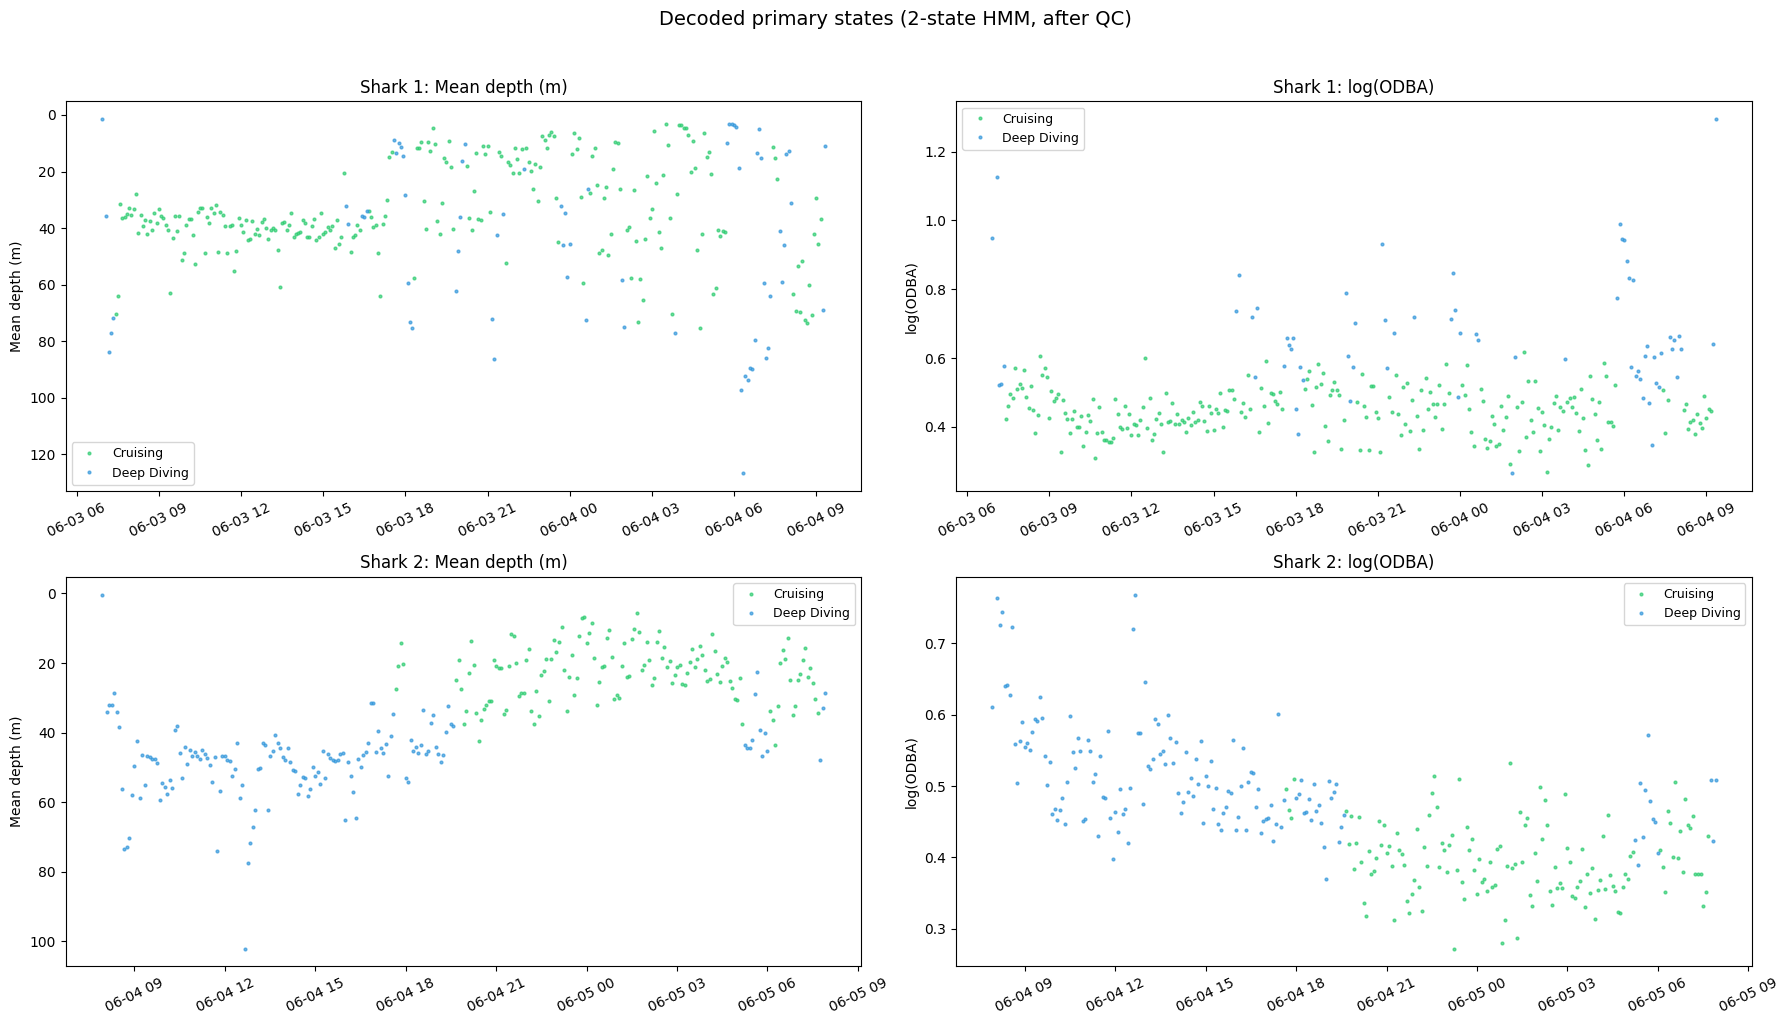

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for col_idx, (var, ylabel) in enumerate([
    ("mean_depth", "Mean depth (m)"),
    ("log_odba", "log(ODBA)")
]):
    for row_idx, (df, name) in enumerate([
        (PRIMARY_SH1, "Shark 1"),
        (PRIMARY_SH2, "Shark 2")
    ]):
        ax = axes[row_idx, col_idx]
        for bio in BIO_ORDER:
            sub = df.loc[df["bio"] == bio].sort_values("time_window")
            ax.plot(sub["time_window"], sub[var], ".", color=BIO_COLORS[bio], ms=4, alpha=0.7, label=BIO_SHORT[bio])
        ax.set_ylabel(ylabel)
        ax.set_title(f"{name}: {ylabel}")
        ax.legend(fontsize=9)
        ax.tick_params(axis="x", rotation=25)
        if var == "mean_depth":
            ax.invert_yaxis()

plt.suptitle("Decoded primary states (2-state HMM, after QC)", fontsize=14, y=1.02)
plt.tight_layout()
savefig("fig05_decoded_primary_timeseries.png")
plt.show()

## 9. Behavioral budgets and diel composition

[saved figure] revised_hmm_outputs/fig06_behavioral_budgets.png


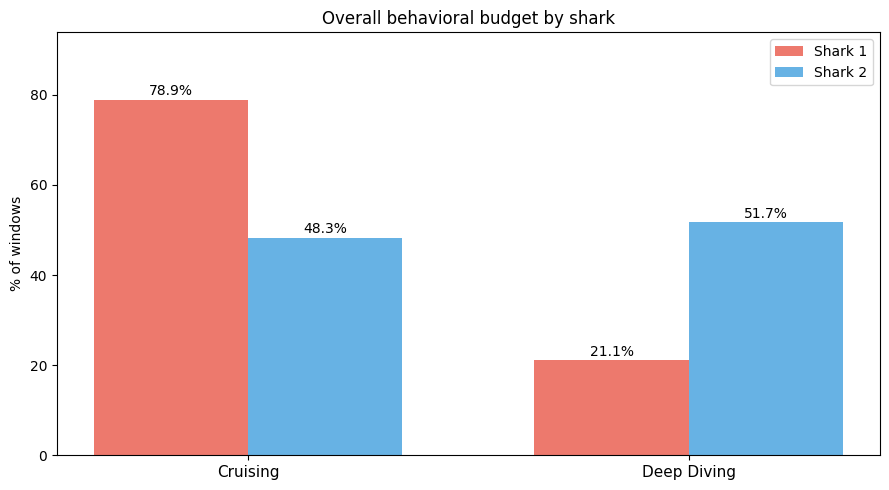

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(BIO_ORDER))
w = 0.35
p1 = [(PRIMARY_SH1["bio"] == b).mean() * 100 for b in BIO_ORDER]
p2 = [(PRIMARY_SH2["bio"] == b).mean() * 100 for b in BIO_ORDER]

bars1 = ax.bar(x - w / 2, p1, w, label="Shark 1", color="#e74c3c", alpha=0.75)
bars2 = ax.bar(x + w / 2, p2, w, label="Shark 2", color="#3498db", alpha=0.75)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f"{h:.1f}%", ha="center", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([BIO_SHORT[b] for b in BIO_ORDER], fontsize=11)
ax.set_ylabel("% of windows")
ax.set_title("Overall behavioral budget by shark")
ax.legend(fontsize=10)
ax.set_ylim(0, max(max(p1), max(p2)) + 15)

plt.tight_layout()
savefig("fig06_behavioral_budgets.png")
plt.show()

[saved figure] revised_hmm_outputs/fig07_diel_composition_by_hour.png


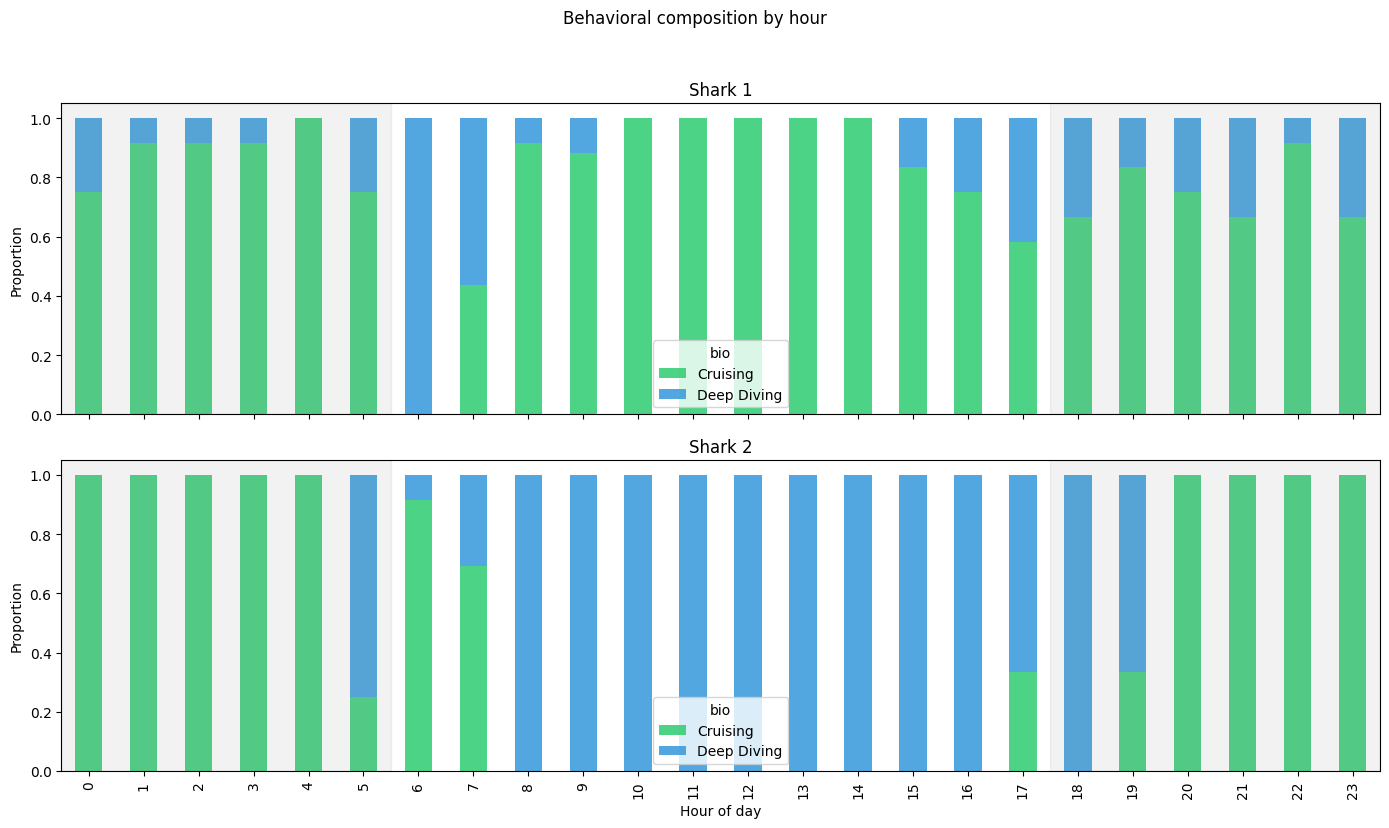

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (df, name) in zip(axes, [(PRIMARY_SH1, "Shark 1"), (PRIMARY_SH2, "Shark 2")]):
    ct = pd.crosstab(df["hour"], df["bio"], normalize="index")
    cols = [b for b in BIO_ORDER if b in ct.columns]
    ct = ct[cols].rename(columns=BIO_SHORT)
    ct.plot.bar(
        stacked=True,
        ax=ax,
        color=[BIO_COLORS[b] for b in cols],
        alpha=0.85
    )
    ax.set_title(name)
    ax.set_ylabel("Proportion")
    ax.axvspan(-0.5, 5.5, color="gray", alpha=0.1)
    ax.axvspan(17.5, 23.5, color="gray", alpha=0.1)

axes[-1].set_xlabel("Hour of day")
plt.suptitle("Behavioral composition by hour", y=1.03)
plt.tight_layout()
savefig("fig07_diel_composition_by_hour.png")
plt.show()

### Day vs night composition and diel profiles

The composition tests below are descriptive of decoded states. They do **not** imply causality, but they are useful for showing whether behavior differs between day and night.

[saved figure] revised_hmm_outputs/fig08_day_night_budgets.png


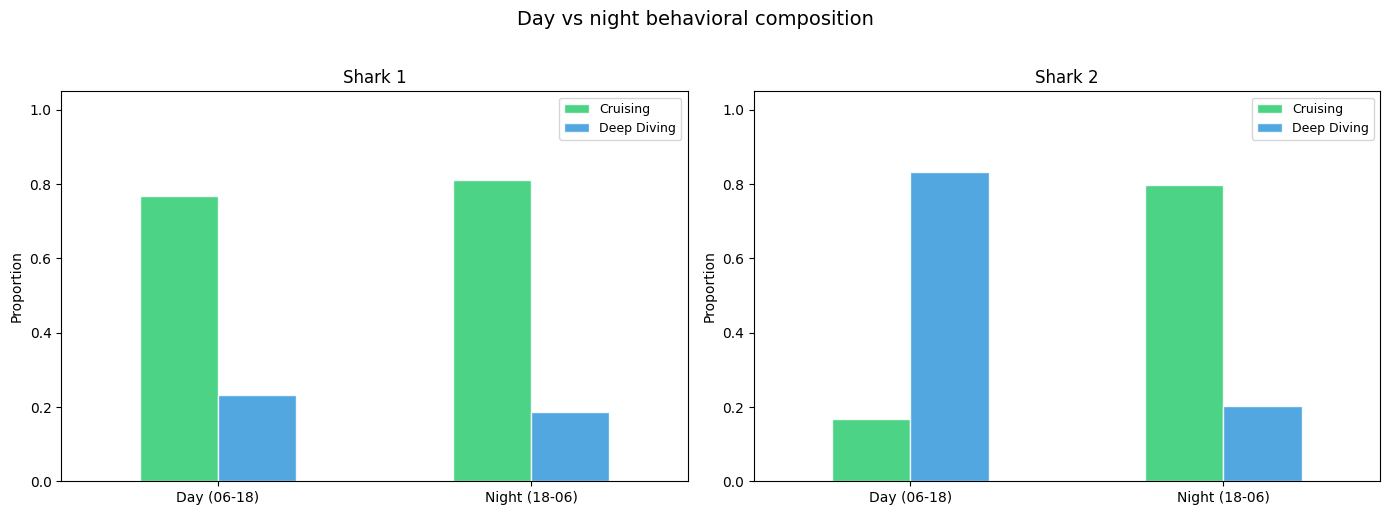


Day vs night chi-squared tests
--------------------------------------------------------------------------------
Shark 1: chi2=0.658, p=0.417, Cramer's V=0.046
[saved table] revised_hmm_outputs/shark_1_day_night_contingency.csv
Shark 2: chi2=112.636, p=2.59e-26, Cramer's V=0.625
[saved table] revised_hmm_outputs/shark_2_day_night_contingency.csv


In [18]:
# Day vs night grouped bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, name) in zip(axes, [(PRIMARY_SH1, "Shark 1"), (PRIMARY_SH2, "Shark 2")]):
    ct = pd.crosstab(df["period"], df["bio"], normalize="index")
    cols = [b for b in BIO_ORDER if b in ct.columns]
    ct = ct[cols].rename(columns=BIO_SHORT)
    ct.plot.bar(
        ax=ax,
        color=[BIO_COLORS[b] for b in cols],
        alpha=0.85,
        edgecolor="white"
    )
    ax.set_title(name)
    ax.set_ylabel("Proportion")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

plt.suptitle("Day vs night behavioral composition", fontsize=14, y=1.02)
plt.tight_layout()
savefig("fig08_day_night_budgets.png")
plt.show()

lp("\nDay vs night chi-squared tests")
lp("-" * 80)
for df, name in [(PRIMARY_SH1, "Shark 1"), (PRIMARY_SH2, "Shark 2")]:
    ct = pd.crosstab(df["period"], df["bio"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    lp(f"{name}: chi2={chi2:.3f}, p={p:.3g}, Cramer's V={v:.3f}")
    save_table(ct.reset_index(), f"{name.lower().replace(' ', '_')}_day_night_contingency.csv", index=False)

[saved figure] revised_hmm_outputs/fig09_diel_profiles_depth_odba.png


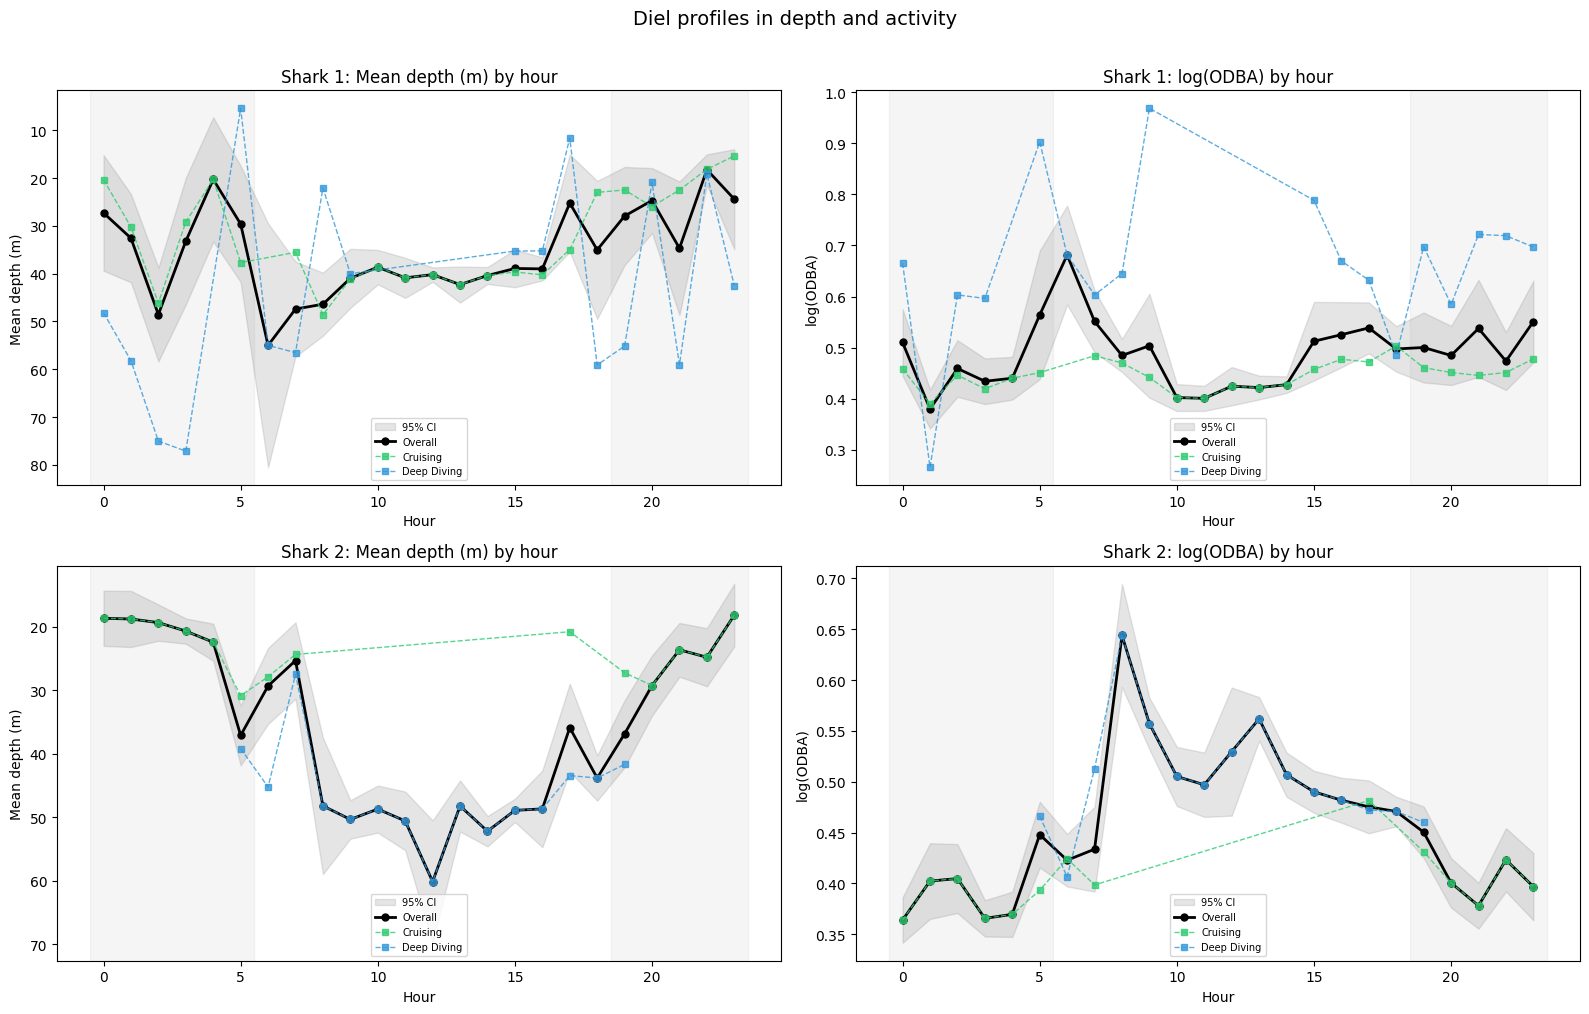

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ci, (var, ylabel) in enumerate([
    ("mean_depth", "Mean depth (m)"),
    ("log_odba", "log(ODBA)")
]):
    for ri, (df, name) in enumerate([
        (PRIMARY_SH1, "Shark 1"),
        (PRIMARY_SH2, "Shark 2")
    ]):
        ax = axes[ri, ci]
        h_all = df.groupby("hour")[var].agg(["mean", "std", "count"]).reset_index()
        h_all["se"] = h_all["std"] / np.sqrt(h_all["count"])
        ax.fill_between(
            h_all["hour"],
            h_all["mean"] - 1.96 * h_all["se"],
            h_all["mean"] + 1.96 * h_all["se"],
            color="gray", alpha=0.2, label="95% CI"
        )
        ax.plot(h_all["hour"], h_all["mean"], "o-", color="black", ms=5, lw=2, label="Overall")

        for bio in BIO_ORDER:
            sub_h = df.loc[df["bio"] == bio].groupby("hour")[var].mean().reset_index()
            ax.plot(sub_h["hour"], sub_h[var], "s--", color=BIO_COLORS[bio], ms=4, lw=1, alpha=0.8, label=BIO_SHORT[bio])

        ax.axvspan(-0.5, 5.5, color="gray", alpha=0.08)
        ax.axvspan(18.5, 23.5, color="gray", alpha=0.08)
        ax.set_xlabel("Hour")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{name}: {ylabel} by hour")
        ax.legend(fontsize=7)
        if var == "mean_depth":
            ax.invert_yaxis()

plt.suptitle("Diel profiles in depth and activity", fontsize=14, y=1.01)
plt.tight_layout()
savefig("fig09_diel_profiles_depth_odba.png")
plt.show()

## 10. Transition analysis done correctly on the full time sequence

Important correction:

We do **not** subset the data into day-only or night-only sequences and then count adjacent states inside those subsets.

Instead:

1. Sort the full decoded sequence by time.
2. Keep only **true consecutive 5-minute steps**.
3. Assign each transition to the **period of the from-state**.

In [20]:
def build_true_transitions(df, window_minutes=5):
    out = df.sort_values("time_window").reset_index(drop=True).copy()
    out["next_time"] = out["time_window"].shift(-1)
    out["next_bio"] = out["bio"].shift(-1)
    expected_gap = pd.Timedelta(minutes=window_minutes)
    out["is_consecutive"] = (out["next_time"] - out["time_window"]) == expected_gap

    trans = out.loc[out["is_consecutive"], ["time_window", "period", "bio", "next_bio"]].copy()
    trans.rename(
        columns={"period": "from_period", "bio": "from_bio", "next_bio": "to_bio"},
        inplace=True
    )
    return trans

def transition_matrix_from_table(trans_df, states):
    mat = pd.crosstab(
        pd.Categorical(trans_df["from_bio"], categories=states),
        pd.Categorical(trans_df["to_bio"], categories=states),
        normalize="index"
    )
    return mat.fillna(0)

trans_sh1 = build_true_transitions(PRIMARY_SH1, WINDOW_MINUTES)
trans_sh2 = build_true_transitions(PRIMARY_SH2, WINDOW_MINUTES)

tpm_sh1_day = transition_matrix_from_table(
    trans_sh1.loc[trans_sh1["from_period"] == "Day (06-18)"], BIO_ORDER
)
tpm_sh1_night = transition_matrix_from_table(
    trans_sh1.loc[trans_sh1["from_period"] == "Night (18-06)"], BIO_ORDER
)
tpm_sh2_day = transition_matrix_from_table(
    trans_sh2.loc[trans_sh2["from_period"] == "Day (06-18)"], BIO_ORDER
)
tpm_sh2_night = transition_matrix_from_table(
    trans_sh2.loc[trans_sh2["from_period"] == "Night (18-06)"], BIO_ORDER
)

save_table(tpm_sh1_day.reset_index(), "table08_tpm_shark1_day.csv", index=False)
save_table(tpm_sh1_night.reset_index(), "table09_tpm_shark1_night.csv", index=False)
save_table(tpm_sh2_day.reset_index(), "table10_tpm_shark2_day.csv", index=False)
save_table(tpm_sh2_night.reset_index(), "table11_tpm_shark2_night.csv", index=False)

lp("\nObserved transition dynamics (true consecutive steps)")
lp("-" * 80)
for label, mat in [
    ("Shark 1 -- Day", tpm_sh1_day),
    ("Shark 1 -- Night", tpm_sh1_night),
    ("Shark 2 -- Day", tpm_sh2_day),
    ("Shark 2 -- Night", tpm_sh2_night),
]:
    diag_parts = ", ".join(
        f"{BIO_SHORT[state]} stay={mat.loc[state, state]:.3f}" for state in BIO_ORDER
    )
    lp(f"{label}: {diag_parts}")

[saved table] revised_hmm_outputs/table08_tpm_shark1_day.csv
[saved table] revised_hmm_outputs/table09_tpm_shark1_night.csv
[saved table] revised_hmm_outputs/table10_tpm_shark2_day.csv
[saved table] revised_hmm_outputs/table11_tpm_shark2_night.csv

Observed transition dynamics (true consecutive steps)
--------------------------------------------------------------------------------
Shark 1 -- Day: Cruising stay=0.962, Deep Diving stay=0.868
Shark 1 -- Night: Cruising stay=0.923, Deep Diving stay=0.667
Shark 2 -- Day: Cruising stay=0.917, Deep Diving stay=0.983
Shark 2 -- Night: Cruising stay=0.991, Deep Diving stay=0.966


[saved figure] revised_hmm_outputs/fig10_transition_dynamics_day_night.png


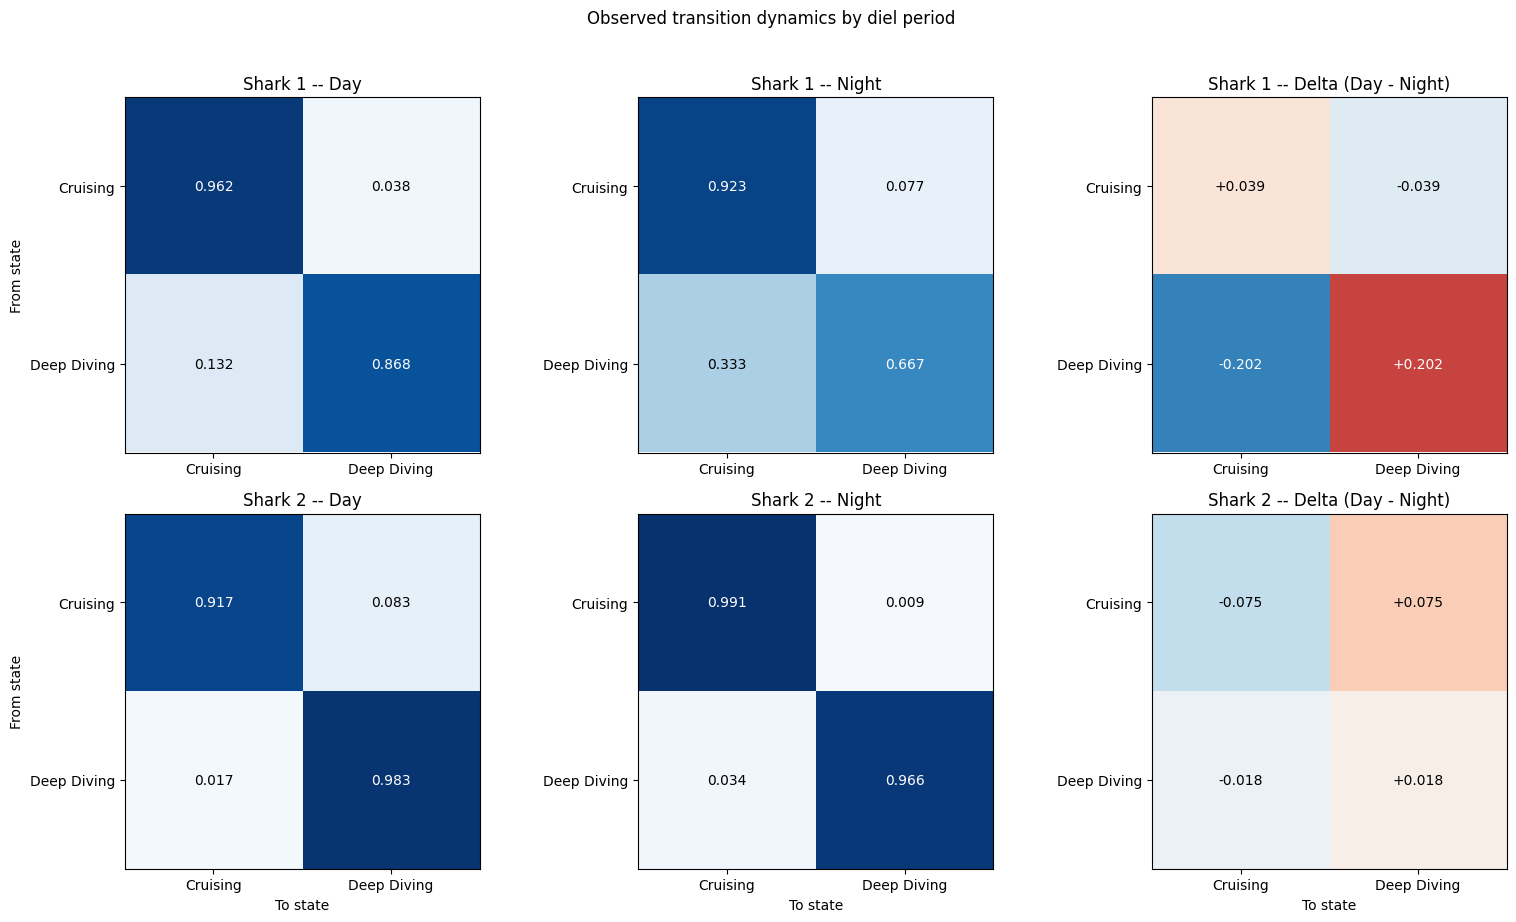

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

def heatmap(ax, mat, title, vmin=0, vmax=1, diff=False):
    arr = mat.to_numpy()
    cmap = "RdBu_r" if diff else "Blues"
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
    ax.set_xticks(range(len(mat.columns)))
    ax.set_yticks(range(len(mat.index)))
    ax.set_xticklabels([BIO_SHORT[c] for c in mat.columns])
    ax.set_yticklabels([BIO_SHORT[r] for r in mat.index])
    ax.set_title(title)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            txt = f"{arr[i, j]:+.3f}" if diff else f"{arr[i, j]:.3f}"
            c = "white" if abs(arr[i, j]) > (0.15 if diff else 0.5) else "black"
            ax.text(j, i, txt, ha="center", va="center", color=c, fontsize=10)
    return im

heatmap(axes[0, 0], tpm_sh1_day, "Shark 1 -- Day")
heatmap(axes[0, 1], tpm_sh1_night, "Shark 1 -- Night")
heatmap(axes[0, 2], tpm_sh1_day - tpm_sh1_night, "Shark 1 -- Delta (Day - Night)", vmin=-0.3, vmax=0.3, diff=True)

heatmap(axes[1, 0], tpm_sh2_day, "Shark 2 -- Day")
heatmap(axes[1, 1], tpm_sh2_night, "Shark 2 -- Night")
heatmap(axes[1, 2], tpm_sh2_day - tpm_sh2_night, "Shark 2 -- Delta (Day - Night)", vmin=-0.3, vmax=0.3, diff=True)

for ax in axes[:, 0]:
    ax.set_ylabel("From state")
for ax in axes[-1, :]:
    ax.set_xlabel("To state")

plt.suptitle("Observed transition dynamics by diel period", y=1.02)
plt.tight_layout()
savefig("fig10_transition_dynamics_day_night.png")
plt.show()

## 11. Cross-shark comparisons within the same labeled behavior

In [22]:
mw_rows = []

lp("\nCross-shark Mann-Whitney tests (same labeled behavior)")
lp("-" * 80)

for bio in BIO_ORDER:
    lp(f"\n{BIO_SHORT[bio]}")
    s1b = PRIMARY_SH1.loc[PRIMARY_SH1["bio"] == bio]
    s2b = PRIMARY_SH2.loc[PRIMARY_SH2["bio"] == bio]

    for var, label in [
        ("mean_depth", "Depth"),
        ("mean_odba", "ODBA"),
        ("mean_temp", "Temperature"),
        ("mean_light_1", "Light")
    ]:
        v1 = s1b[var].dropna()
        v2 = s2b[var].dropna()
        if len(v1) >= 3 and len(v2) >= 3:
            u, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
            mw_rows.append({
                "behavior": bio,
                "variable": label,
                "shark1_mean": v1.mean(),
                "shark2_mean": v2.mean(),
                "U": u,
                "p_value": p
            })
            lp(f"  {label}: Shark 1 mean={v1.mean():.3f}, Shark 2 mean={v2.mean():.3f}, p={p:.4g}")

mw_table = pd.DataFrame(mw_rows)
display(mw_table)
save_table(mw_table, "table12_mannwhitney_cross_shark.csv", index=False)


Cross-shark Mann-Whitney tests (same labeled behavior)
--------------------------------------------------------------------------------

Cruising
  Depth: Shark 1 mean=34.183, Shark 2 mean=22.699, p=2.944e-14
  ODBA: Shark 1 mean=0.564, Shark 2 mean=0.489, p=1.196e-12
  Temperature: Shark 1 mean=23.276, Shark 2 mean=23.573, p=0.08081
  Light: Shark 1 mean=15906.594, Shark 2 mean=3176.258, p=2.774e-18

Deep Diving
  Depth: Shark 1 mean=44.990, Shark 2 mean=47.881, p=0.1552
  ODBA: Shark 1 mean=0.969, Shark 2 mean=0.674, p=3.37e-14
  Temperature: Shark 1 mean=22.284, Shark 2 mean=22.928, p=0.2157
  Light: Shark 1 mean=9784.021, Shark 2 mean=16353.205, p=3.506e-06


,behavior,variable,shark1_mean,shark2_mean,U,p_value
0,Cruising / Routine Swimming,Depth,34.183064,22.699497,25453.0,2.943623e-14
1,Cruising / Routine Swimming,ODBA,0.563936,0.488968,24927.0,1.196111e-12
2,Cruising / Routine Swimming,Temperature,23.275858,23.573238,15519.0,8.081260e-02
3,Cruising / Routine Swimming,Light,15906.593718,3176.257719,25872.5,2.774218e-18
4,Deep Diving / Active Diving,Depth,44.989888,47.880589,4387.0,1.551522e-01
5,Deep Diving / Active Diving,ODBA,0.968865,0.674424,8214.0,3.369872e-14
6,Deep Diving / Active Diving,Temperature,22.284450,22.927607,4465.0,2.157210e-01
7,Deep Diving / Active Diving,Light,9784.020842,16353.204691,3021.0,3.506099e-06


[saved table] revised_hmm_outputs/table12_mannwhitney_cross_shark.csv


PosixPath('revised_hmm_outputs/table12_mannwhitney_cross_shark.csv')

[saved figure] revised_hmm_outputs/fig11_cross_shark_violins.png


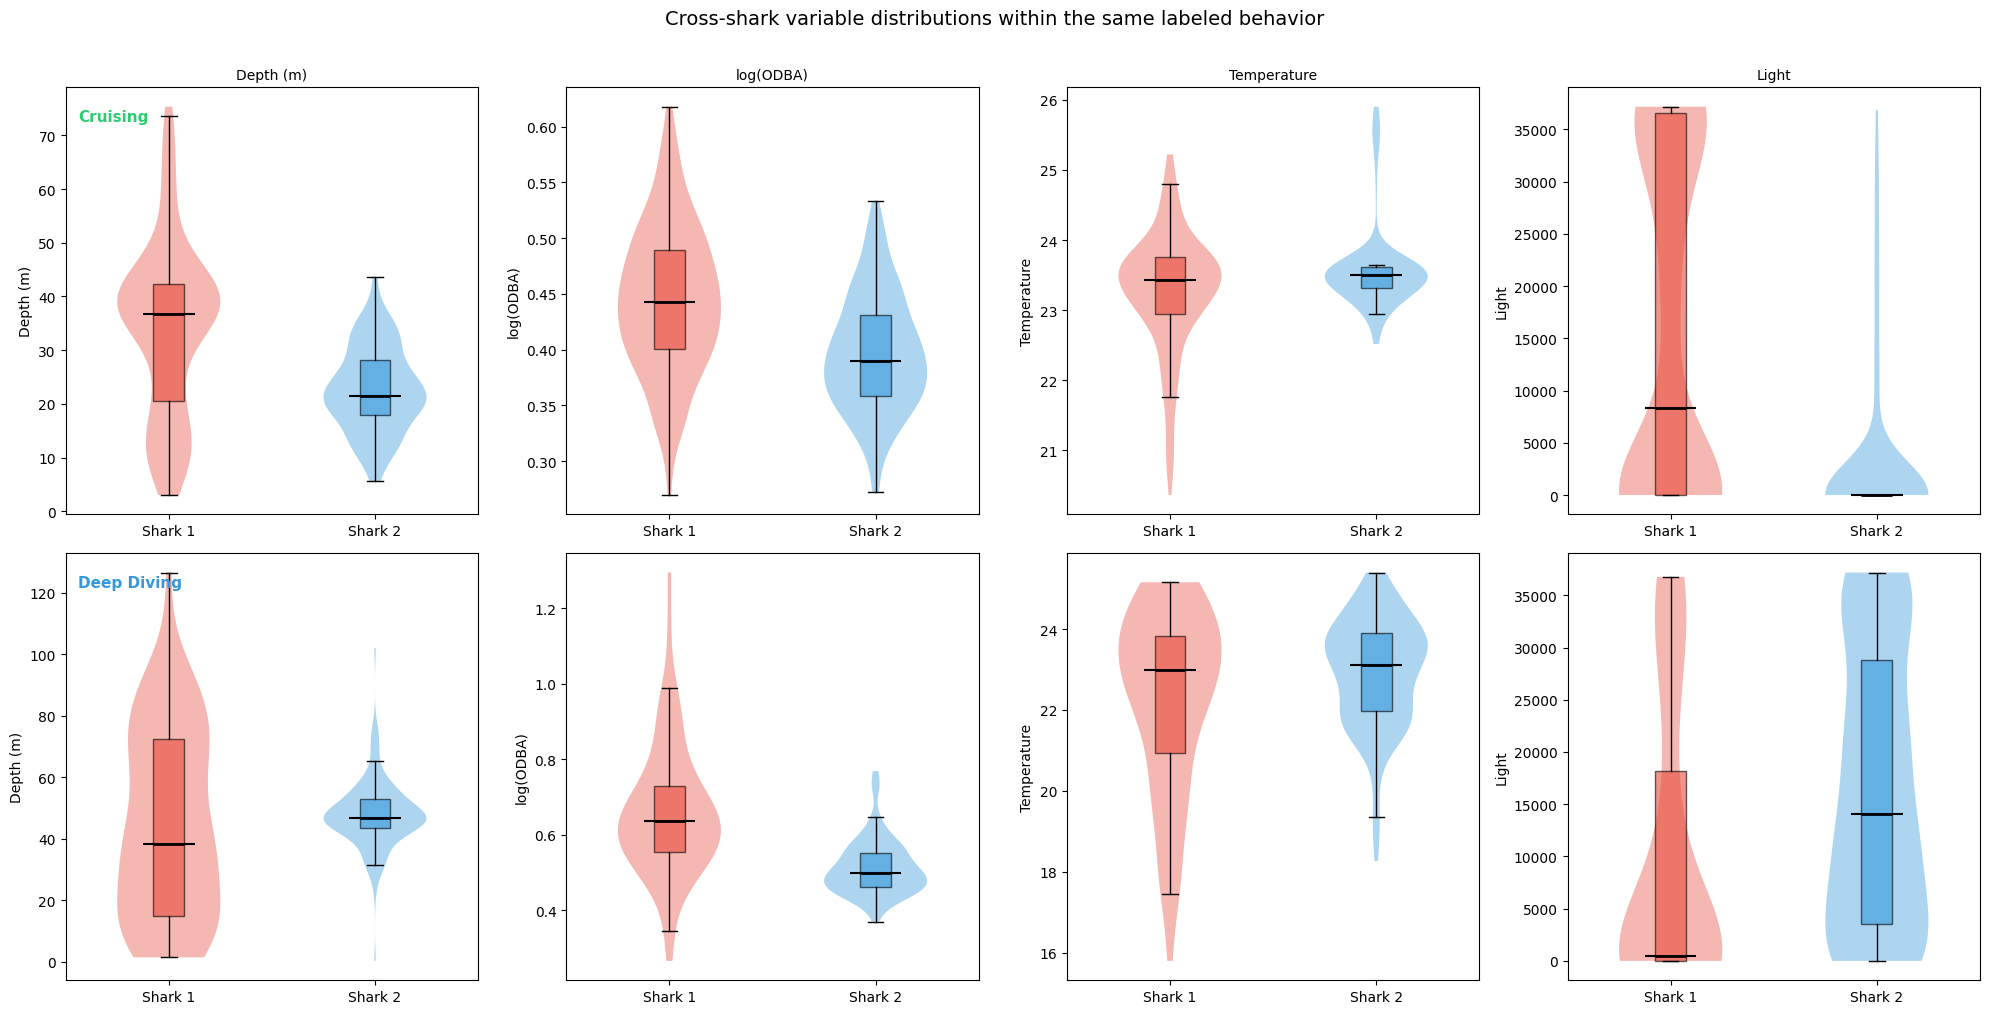

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

plot_vars = [
    ("mean_depth", "Depth (m)"),
    ("log_odba", "log(ODBA)"),
    ("mean_temp", "Temperature"),
    ("mean_light_1", "Light")
]

for row_idx, bio in enumerate(BIO_ORDER):
    for col_idx, (var, ylabel) in enumerate(plot_vars):
        ax = axes[row_idx, col_idx]
        v1 = PRIMARY_SH1.loc[PRIMARY_SH1["bio"] == bio, var].dropna().values
        v2 = PRIMARY_SH2.loc[PRIMARY_SH2["bio"] == bio, var].dropna().values

        parts = ax.violinplot([v1, v2], positions=[1, 2], showmedians=True, showextrema=False)
        for body, color in zip(parts["bodies"], ["#e74c3c", "#3498db"]):
            body.set_facecolor(color)
            body.set_alpha(0.4)
        parts["cmedians"].set_color("black")

        bp = ax.boxplot(
            [v1, v2], positions=[1, 2], widths=0.15, patch_artist=True,
            showfliers=False, medianprops={"color": "black", "linewidth": 2}
        )
        for patch, color in zip(bp["boxes"], ["#e74c3c", "#3498db"]):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)

        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Shark 1", "Shark 2"])
        ax.set_ylabel(ylabel)
        if row_idx == 0:
            ax.set_title(ylabel, fontsize=10)
        if col_idx == 0:
            ax.text(0.03, 0.95, BIO_SHORT[bio], transform=ax.transAxes,
                    ha="left", va="top", fontsize=11, fontweight="bold", color=BIO_COLORS[bio])

plt.suptitle("Cross-shark variable distributions within the same labeled behavior", fontsize=14, y=1.01)
plt.tight_layout()
savefig("fig11_cross_shark_violins.png")
plt.show()

## 12. Jensen-Shannon divergence by hour

,hour,jsd
0,0,0.309197
1,1,0.172590
2,2,0.172590
3,3,0.172590
4,4,0.000000
5,5,0.361679
6,6,0.739089
7,7,0.184717
8,8,0.739089
9,9,0.710708


[saved table] revised_hmm_outputs/table13_jsd_by_hour.csv
[saved figure] revised_hmm_outputs/fig12_jsd_by_hour.png


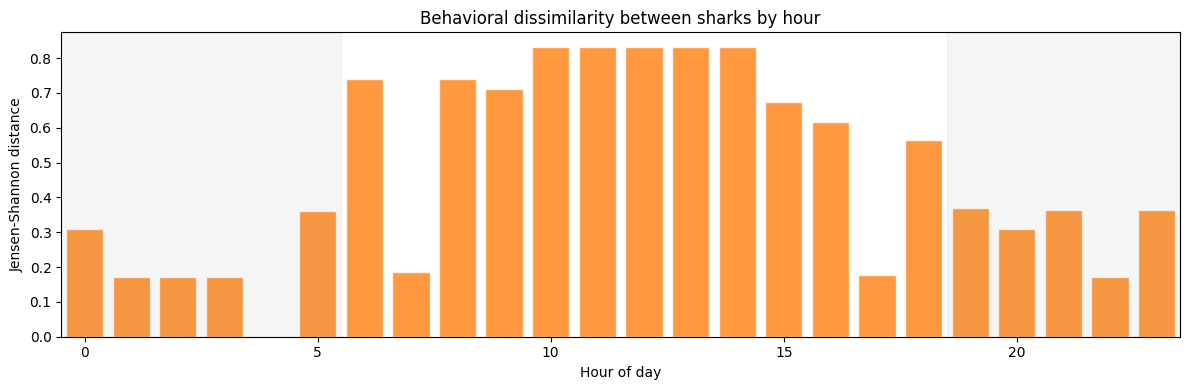


Jensen-Shannon divergence by hour
--------------------------------------------------------------------------------
Mean JSD=0.472; most similar=04:00 (0.000); most different=10:00 (0.833)


In [24]:
js_hours = []
for h in range(24):
    s1h = PRIMARY_SH1.loc[PRIMARY_SH1["hour"] == h]
    s2h = PRIMARY_SH2.loc[PRIMARY_SH2["hour"] == h]

    if len(s1h) == 0 or len(s2h) == 0:
        js_hours.append(np.nan)
        continue

    p1 = np.array([(s1h["bio"] == b).mean() for b in BIO_ORDER]) + 1e-10
    p2 = np.array([(s2h["bio"] == b).mean() for b in BIO_ORDER]) + 1e-10
    js_hours.append(jensenshannon(p1 / p1.sum(), p2 / p2.sum()))

jsd_table = pd.DataFrame({"hour": range(24), "jsd": js_hours})
display(jsd_table)
save_table(jsd_table, "table13_jsd_by_hour.csv", index=False)

vh = [h for h, v in enumerate(js_hours) if not np.isnan(v)]
vj = [js_hours[h] for h in vh]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(vh, vj, color="tab:orange", alpha=0.8, edgecolor="white")
ax.axvspan(-0.5, 5.5, color="gray", alpha=0.08)
ax.axvspan(18.5, 23.5, color="gray", alpha=0.08)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Jensen-Shannon distance")
ax.set_title("Behavioral dissimilarity between sharks by hour")
ax.set_xlim(-0.5, 23.5)

plt.tight_layout()
savefig("fig12_jsd_by_hour.png")
plt.show()

lp("\nJensen-Shannon divergence by hour")
lp("-" * 80)
lp(
    f"Mean JSD={np.nanmean(vj):.3f}; "
    f"most similar={vh[np.argmin(vj)]:02d}:00 ({min(vj):.3f}); "
    f"most different={vh[np.argmax(vj)]:02d}:00 ({max(vj):.3f})"
)

## 13. Light analysis: descriptive only

This section stays intentionally conservative.

What you *can* say from this notebook:
- light clearly tracks diel context,
- and light can help describe when behaviors occur.

What you should *not* claim from this notebook alone:
- that light has been formally modeled as a transition covariate in a non-homogeneous HMM.

[saved figure] revised_hmm_outputs/fig13_light_as_diel_proxy.png


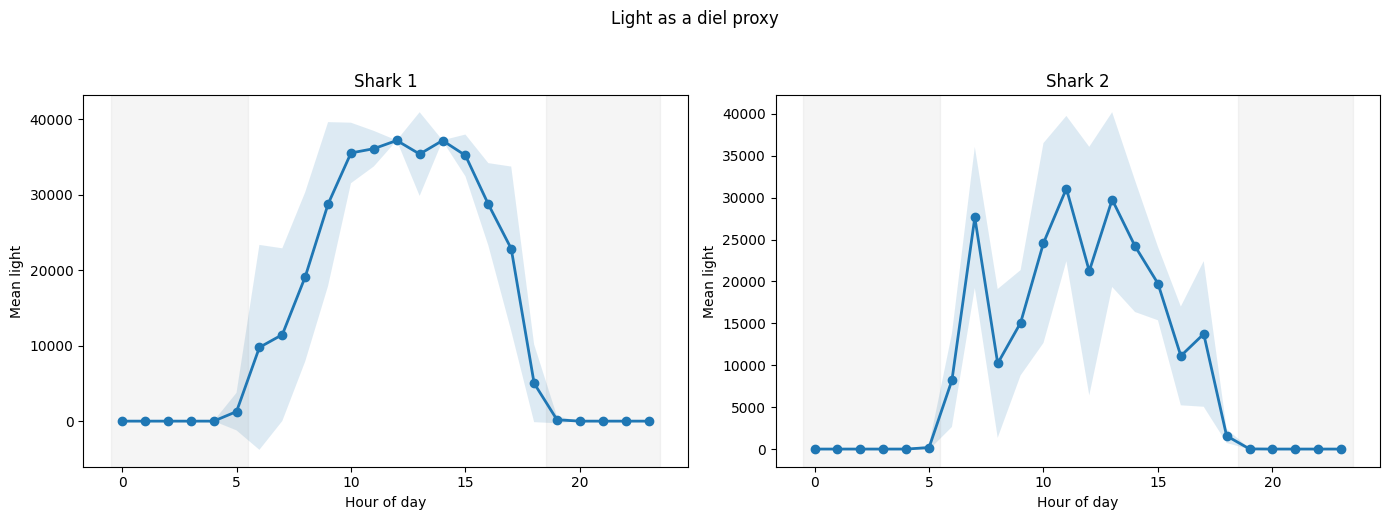

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, name) in zip(axes, [(PRIMARY_SH1, "Shark 1"), (PRIMARY_SH2, "Shark 2")]):
    hourly = df.groupby("hour")["mean_light_1"].agg(["mean", "std"]).reset_index()
    ax.plot(hourly["hour"], hourly["mean"], "o-", lw=2)
    ax.fill_between(hourly["hour"], hourly["mean"] - hourly["std"], hourly["mean"] + hourly["std"], alpha=0.15)
    ax.axvspan(-0.5, 5.5, color="gray", alpha=0.08)
    ax.axvspan(18.5, 23.5, color="gray", alpha=0.08)
    ax.set_title(name)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Mean light")

plt.suptitle("Light as a diel proxy", y=1.03)
plt.tight_layout()
savefig("fig13_light_as_diel_proxy.png")
plt.show()

[saved figure] revised_hmm_outputs/fig14_within_state_light_day_night.png


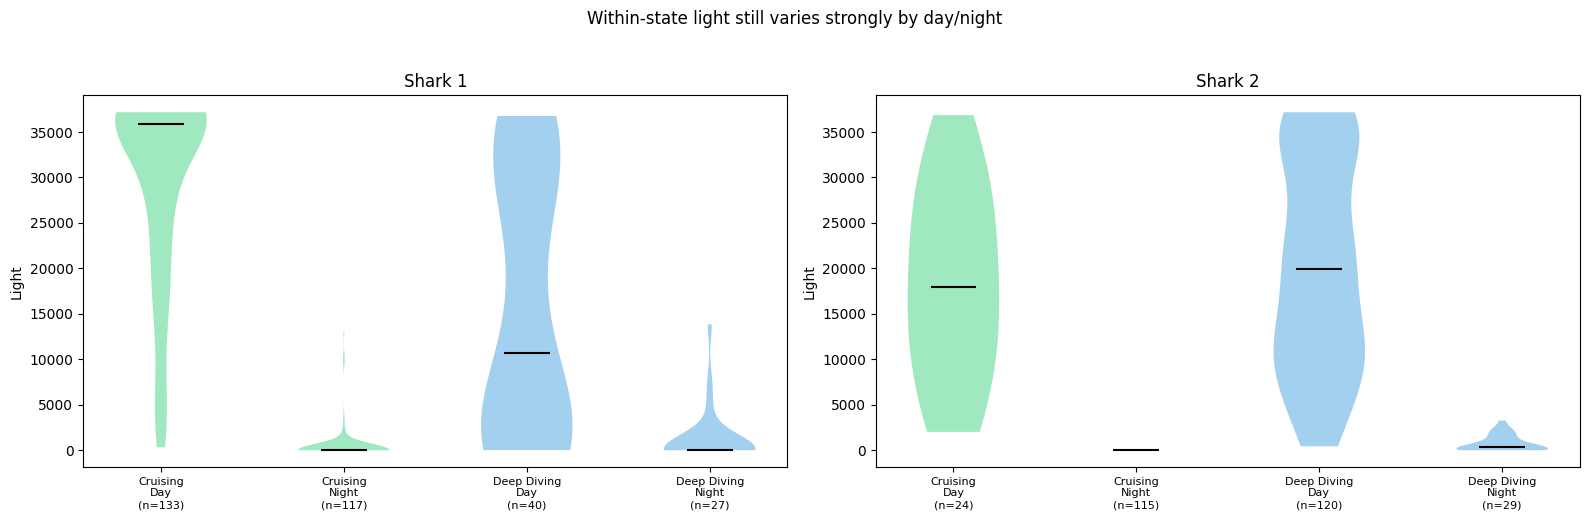

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df, name) in zip(axes, [(PRIMARY_SH1, "Shark 1"), (PRIMARY_SH2, "Shark 2")]):
    data = []
    labels = []
    colors = []

    for bio in BIO_ORDER:
        for is_day, lab in [(True, "Day"), (False, "Night")]:
            sub = df.loc[(df["bio"] == bio) & (df["is_day"] == is_day)]
            if len(sub) > 0:
                data.append(sub["mean_light_1"].dropna().values)
                labels.append(f"{BIO_SHORT[bio]}\n{lab}\n(n={len(sub)})")
                colors.append(BIO_COLORS[bio])

    parts = ax.violinplot(data, showmedians=True, showextrema=False)
    for body, color in zip(parts["bodies"], colors):
        body.set_facecolor(color)
        body.set_alpha(0.45)
    parts["cmedians"].set_color("black")

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Light")
    ax.set_title(name)

plt.suptitle("Within-state light still varies strongly by day/night", y=1.03)
plt.tight_layout()
savefig("fig14_within_state_light_day_night.png")
plt.show()

## 14. Optional sensitivity analysis

Uncomment and run this only if you want to show that your conclusions are not overly sensitive to the exact detachment threshold.

In [27]:
def detachment_sensitivity_summary(shark_df, depth_grid, odba_grid):
    rows = []
    for dthr in depth_grid:
        for othr in odba_grid:
            tmp = flag_candidate_detachment(shark_df, dthr, othr)
            tmp, runs = choose_detachment_windows(
                tmp,
                buffer_windows=DETACH_BUFFER_WINDOWS,
                startup_artifact_max_index=STARTUP_ARTIFACT_MAX_INDEX
            )
            rows.append({
                "depth_thresh": dthr,
                "odba_thresh": othr,
                "n_removed": int(tmp["remove_detach"].sum())
            })
    return pd.DataFrame(rows)

# Example:
# sens1 = detachment_sensitivity_summary(
#     shark1_win_raw.drop(columns=["candidate_detach", "remove_detach"], errors="ignore"),
#     depth_grid=[3, 5, 8],
#     odba_grid=[1.5, 2.0, 2.5]
# )
# sens2 = detachment_sensitivity_summary(
#     shark2_win_raw.drop(columns=["candidate_detach", "remove_detach"], errors="ignore"),
#     depth_grid=[3, 5, 8],
#     odba_grid=[1.5, 2.0, 2.5]
# )
# display(sens1)
# display(sens2)
# save_table(sens1, "table14_sensitivity_shark1.csv", index=False)
# save_table(sens2, "table15_sensitivity_shark2.csv", index=False)

## 15. Final collaborator-safe summary

In [28]:
lp("\nFINAL SUMMARY")
lp("=" * 80)
lp(
    "1) Candidate detachment windows were handled as a QC/artifact problem, "
    "not as a biological state."
)
lp(
    "2) Both 2-state and 3-state HMMs were fit after QC. The 2-state model is "
    "used here as the main biological workflow for interpretability and "
    "cross-shark comparability."
)
lp(
    "3) If 3-state models still outperform by AIC/BIC, they should be reported "
    "as secondary evidence of additional substructure rather than ignored."
)
lp(
    "4) Day/night transition analysis was based only on true consecutive "
    "5-minute steps, avoiding artificial transitions created by subsetting."
)
lp(
    "5) Light is treated here as a descriptive diel-context variable. Stronger "
    "claims about light-driven transitions would require a true covariate-HMM."
)

lp("\nFiles written to output directory:")
for p in sorted(OUTPUT_DIR.iterdir()):
    lp(" -", p.name)

print(f"\nDone. See outputs in: {OUTPUT_DIR.resolve()}")


FINAL SUMMARY
1) Candidate detachment windows were handled as a QC/artifact problem, not as a biological state.
2) Both 2-state and 3-state HMMs were fit after QC. The 2-state model is used here as the main biological workflow for interpretability and cross-shark comparability.
3) If 3-state models still outperform by AIC/BIC, they should be reported as secondary evidence of additional substructure rather than ignored.
4) Day/night transition analysis was based only on true consecutive 5-minute steps, avoiding artificial transitions created by subsetting.
5) Light is treated here as a descriptive diel-context variable. Stronger claims about light-driven transitions would require a true covariate-HMM.

Files written to output directory:
 - analysis_log.txt
 - fig01_detachment_space.png
 - fig02_detachment_timeseries.png
 - fig03_model_comparison_aic_bic.png
 - fig04_state_structure_2state_3state.png
 - fig05_decoded_primary_timeseries.png
 - fig06_behavioral_budgets.png
 - fig07_diel_c

In [29]:
# ============================================================
# SUPPLEMENTARY: 3-state decode inspection
# ============================================================

def label_3state_by_depth(df):
    tab = hmm_summary_table(df).sort_values(["mean_depth", "mean_odba"]).reset_index(drop=True)
    ordered_states = tab["state"].astype(int).tolist()

    mapping = {
        ordered_states[0]: "Shallow state",
        ordered_states[1]: "Mid-depth state",
        ordered_states[2]: "Deep / high-activity state"
    }

    out = df.copy()
    out["bio3"] = out["state"].map(mapping)
    return out, mapping, tab

SH1_3, MAP3_SH1, TAB3_SH1 = label_3state_by_depth(shark1_res_3)
SH2_3, MAP3_SH2, TAB3_SH2 = label_3state_by_depth(shark2_res_3)

BIO3_ORDER = ["Shallow state", "Mid-depth state", "Deep / high-activity state"]
BIO3_SHORT = {
    "Shallow state": "Shallow",
    "Mid-depth state": "Mid",
    "Deep / high-activity state": "Deep/Active"
}
BIO3_COLORS = {
    "Shallow state": "#2ECC71",
    "Mid-depth state": "#F39C12",
    "Deep / high-activity state": "#3498DB"
}

def state_summary_by_behavior3(df):
    return (
        df.groupby("bio3", as_index=False)
        .agg(
            n=("bio3", "size"),
            mean_depth=("mean_depth", "mean"),
            sd_depth=("mean_depth", "std"),
            mean_odba=("mean_odba", "mean"),
            sd_odba=("mean_odba", "std"),
            mean_temp=("mean_temp", "mean"),
            mean_light_1=("mean_light_1", "mean")
        )
        .assign(prop=lambda x: x["n"] / x["n"].sum())
    )

SUM3_SH1 = state_summary_by_behavior3(SH1_3)
SUM3_SH2 = state_summary_by_behavior3(SH2_3)

display(SUM3_SH1)
display(SUM3_SH2)

save_table(SUM3_SH1, "table16_shark1_3state_labeled_summary.csv", index=False)
save_table(SUM3_SH2, "table17_shark2_3state_labeled_summary.csv", index=False)

lp("\n3-state decode inspection")
lp("-" * 80)
lp("Shark 1 3-state mapping:", MAP3_SH1)
lp("Shark 2 3-state mapping:", MAP3_SH2)

for name, df in [("Shark 1", SH1_3), ("Shark 2", SH2_3)]:
    lp(f"\n{name}")
    for bio in BIO3_ORDER:
        sub = df[df["bio3"] == bio]
        lp(
            f"  {BIO3_SHORT[bio]}: n={len(sub)} ({len(sub)/len(df):.1%}), "
            f"depth={sub['mean_depth'].mean():.2f}±{sub['mean_depth'].std():.2f}, "
            f"ODBA={sub['mean_odba'].mean():.3f}, "
            f"temp={sub['mean_temp'].mean():.2f}, "
            f"light={sub['mean_light_1'].mean():.1f}"
        )

,bio3,n,mean_depth,sd_depth,mean_odba,sd_odba,mean_temp,mean_light_1,prop
0,Deep / high-activity state,92,53.199941,24.509702,0.822822,0.387753,21.976524,4771.637365,0.290221
1,Mid-depth state,141,39.395571,5.237375,0.555349,0.096827,23.285704,26002.867342,0.444795
2,Shallow state,84,13.225220,5.596696,0.617786,0.147520,23.891643,6271.224919,0.264984


,bio3,n,mean_depth,sd_depth,mean_odba,sd_odba,mean_temp,mean_light_1,prop
0,Deep / high-activity state,29,51.203951,20.822115,0.849282,0.148467,22.566655,11615.998092,0.100694
1,Mid-depth state,117,47.362090,6.559245,0.634141,0.078316,23.017985,17946.687037,0.406250
2,Shallow state,142,22.979991,8.021115,0.490367,0.078178,23.558847,3109.161930,0.493056


[saved table] revised_hmm_outputs/table16_shark1_3state_labeled_summary.csv
[saved table] revised_hmm_outputs/table17_shark2_3state_labeled_summary.csv

3-state decode inspection
--------------------------------------------------------------------------------
Shark 1 3-state mapping: {1: 'Shallow state', 3: 'Mid-depth state', 2: 'Deep / high-activity state'}
Shark 2 3-state mapping: {1: 'Shallow state', 2: 'Mid-depth state', 3: 'Deep / high-activity state'}

Shark 1
  Shallow: n=84 (26.5%), depth=13.23±5.60, ODBA=0.618, temp=23.89, light=6271.2
  Mid: n=141 (44.5%), depth=39.40±5.24, ODBA=0.555, temp=23.29, light=26002.9
  Deep/Active: n=92 (29.0%), depth=53.20±24.51, ODBA=0.823, temp=21.98, light=4771.6

Shark 2
  Shallow: n=142 (49.3%), depth=22.98±8.02, ODBA=0.490, temp=23.56, light=3109.2
  Mid: n=117 (40.6%), depth=47.36±6.56, ODBA=0.634, temp=23.02, light=17946.7
  Deep/Active: n=29 (10.1%), depth=51.20±20.82, ODBA=0.849, temp=22.57, light=11616.0


[saved figure] revised_hmm_outputs/fig15_decoded_3state_timeseries.png


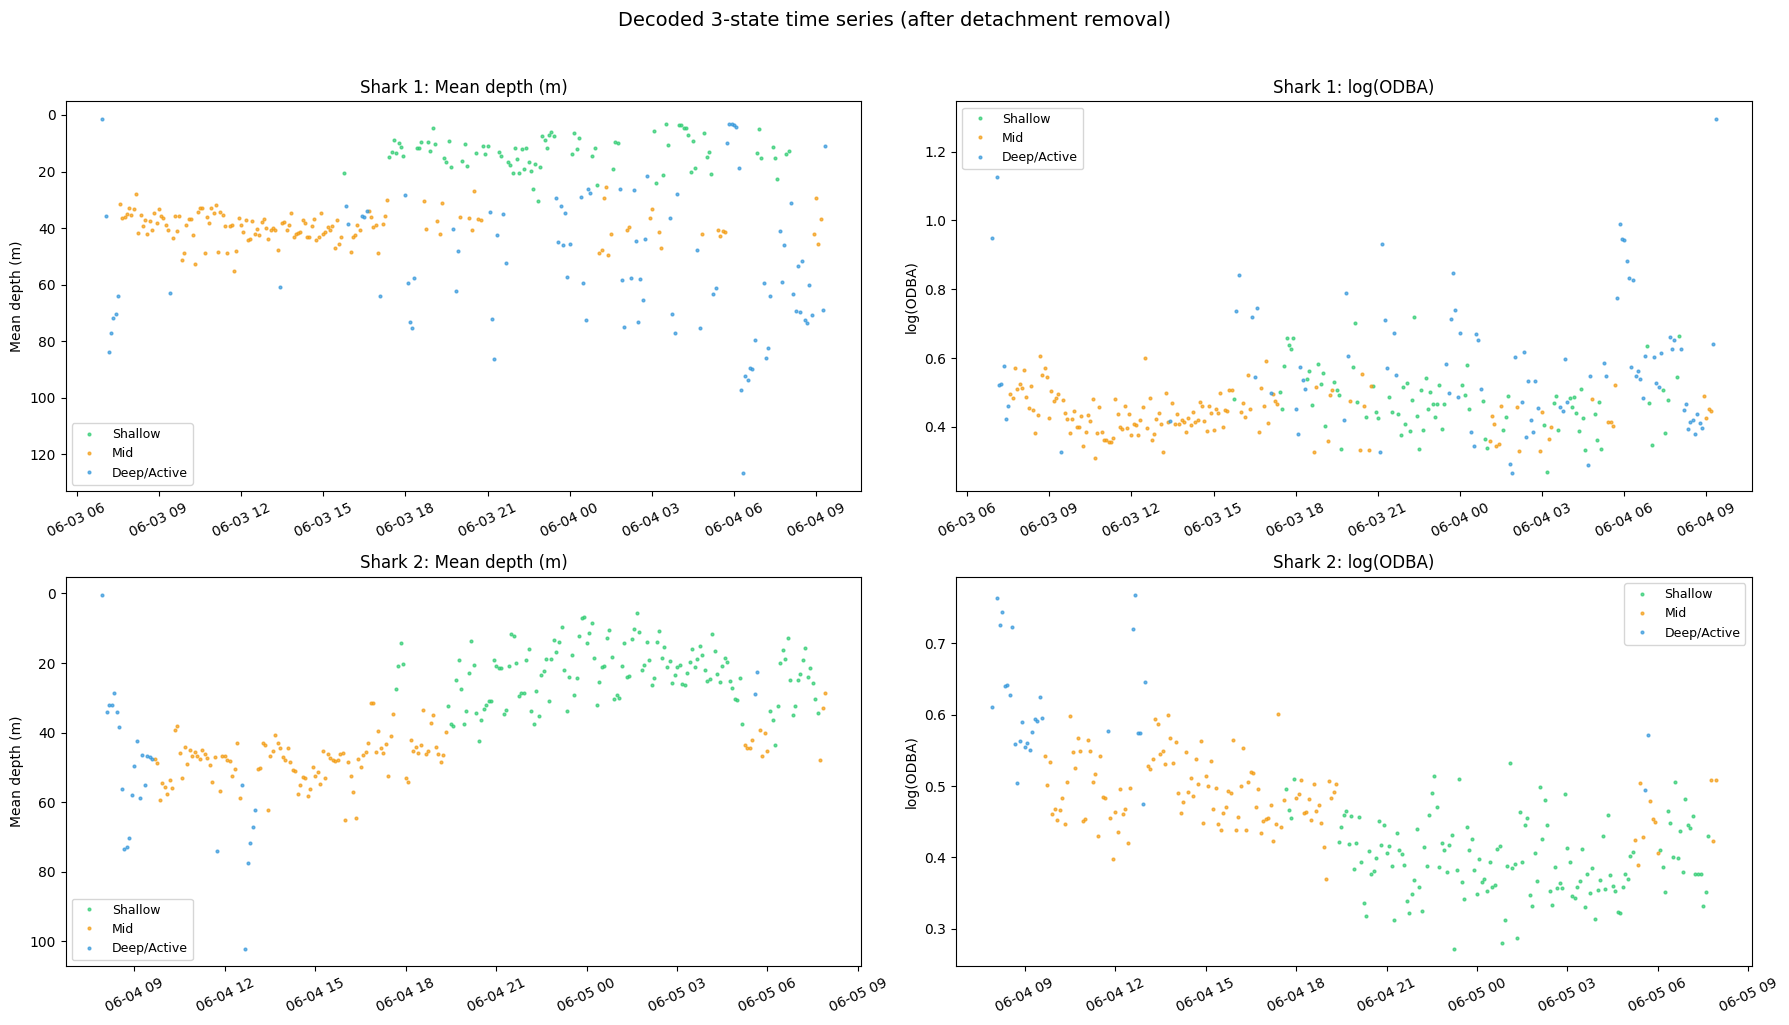

In [30]:
# ============================================================
# 3-state decoded time series
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for col_idx, (var, ylabel) in enumerate([
    ("mean_depth", "Mean depth (m)"),
    ("log_odba", "log(ODBA)")
]):
    for row_idx, (df, name) in enumerate([
        (SH1_3, "Shark 1"),
        (SH2_3, "Shark 2")
    ]):
        ax = axes[row_idx, col_idx]
        for bio in BIO3_ORDER:
            sub = df[df["bio3"] == bio].sort_values("time_window")
            ax.plot(
                sub["time_window"], sub[var], ".",
                color=BIO3_COLORS[bio], ms=4, alpha=0.7,
                label=BIO3_SHORT[bio]
            )
        ax.set_ylabel(ylabel)
        ax.set_title(f"{name}: {ylabel}")
        ax.legend(fontsize=9)
        ax.tick_params(axis="x", rotation=25)
        if var == "mean_depth":
            ax.invert_yaxis()

plt.suptitle("Decoded 3-state time series (after detachment removal)", fontsize=14, y=1.02)
plt.tight_layout()
savefig("fig15_decoded_3state_timeseries.png")
plt.show()

[saved figure] revised_hmm_outputs/fig16_3state_diel_composition_by_hour.png


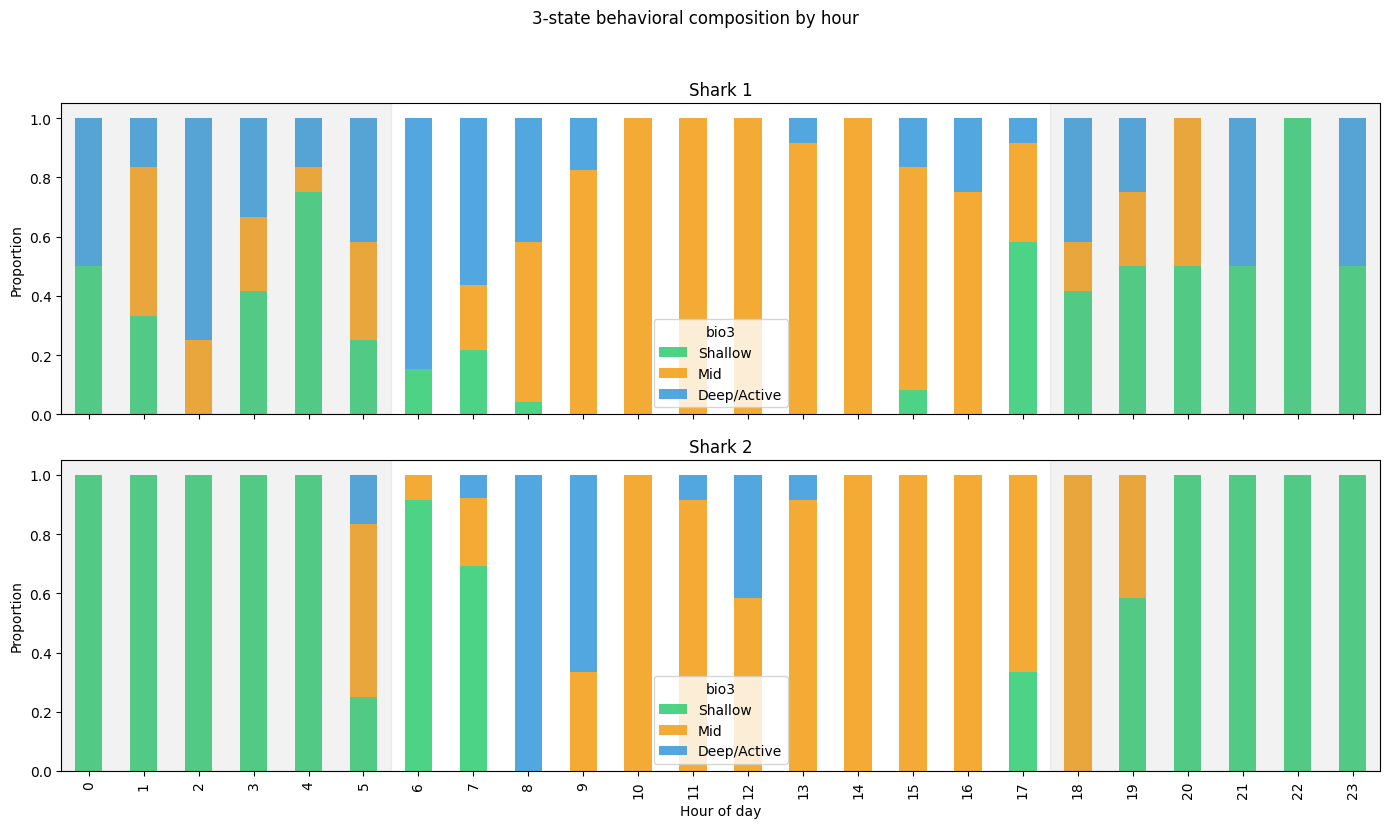

[saved figure] revised_hmm_outputs/fig17_3state_day_night_budgets.png


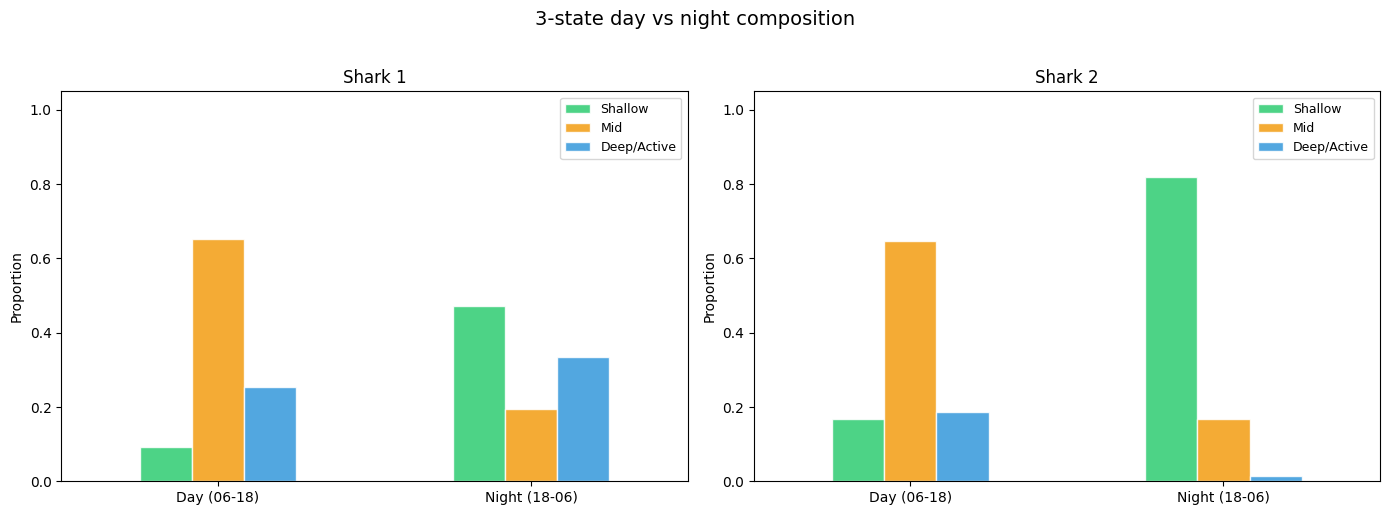


3-state day vs night chi-squared tests
--------------------------------------------------------------------------------
Shark 1: chi2=81.636, p=1.88e-18, Cramer's V=0.507
[saved table] revised_hmm_outputs/shark_1_3state_day_night_contingency.csv
Shark 2: chi2=124.469, p=9.37e-28, Cramer's V=0.657
[saved table] revised_hmm_outputs/shark_2_3state_day_night_contingency.csv


In [31]:
# ============================================================
# 3-state diel composition
# ============================================================

# Hourly stacked composition
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (df, name) in zip(axes, [(SH1_3, "Shark 1"), (SH2_3, "Shark 2")]):
    ct = pd.crosstab(df["hour"], df["bio3"], normalize="index")
    cols = [b for b in BIO3_ORDER if b in ct.columns]
    ct = ct[cols].rename(columns=BIO3_SHORT)

    ct.plot.bar(
        stacked=True,
        ax=ax,
        color=[BIO3_COLORS[b] for b in cols],
        alpha=0.85
    )
    ax.set_title(name)
    ax.set_ylabel("Proportion")
    ax.axvspan(-0.5, 5.5, color="gray", alpha=0.1)
    ax.axvspan(17.5, 23.5, color="gray", alpha=0.1)

axes[-1].set_xlabel("Hour of day")
plt.suptitle("3-state behavioral composition by hour", y=1.03)
plt.tight_layout()
savefig("fig16_3state_diel_composition_by_hour.png")
plt.show()


# Day vs night grouped bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, name) in zip(axes, [(SH1_3, "Shark 1"), (SH2_3, "Shark 2")]):
    ct = pd.crosstab(df["period"], df["bio3"], normalize="index")
    cols = [b for b in BIO3_ORDER if b in ct.columns]
    ct = ct[cols].rename(columns=BIO3_SHORT)

    ct.plot.bar(
        ax=ax,
        color=[BIO3_COLORS[b] for b in cols],
        alpha=0.85,
        edgecolor="white"
    )
    ax.set_title(name)
    ax.set_ylabel("Proportion")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

plt.suptitle("3-state day vs night composition", fontsize=14, y=1.02)
plt.tight_layout()
savefig("fig17_3state_day_night_budgets.png")
plt.show()


# Chi-square
lp("\n3-state day vs night chi-squared tests")
lp("-" * 80)

for df, name in [(SH1_3, "Shark 1"), (SH2_3, "Shark 2")]:
    ct = pd.crosstab(df["period"], df["bio3"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    lp(f"{name}: chi2={chi2:.3f}, p={p:.3g}, Cramer's V={v:.3f}")
    save_table(ct.reset_index(), f"{name.lower().replace(' ', '_')}_3state_day_night_contingency.csv", index=False)

In [32]:
# ============================================================
# 3-state transition dynamics (corrected: true consecutive steps)
# ============================================================

def build_true_transitions_3state(df, window_minutes=5):
    out = df.sort_values("time_window").reset_index(drop=True).copy()
    out["next_time"] = out["time_window"].shift(-1)
    out["next_bio3"] = out["bio3"].shift(-1)
    expected_gap = pd.Timedelta(minutes=window_minutes)
    out["is_consecutive"] = (out["next_time"] - out["time_window"]) == expected_gap

    trans = out.loc[out["is_consecutive"], ["time_window", "period", "bio3", "next_bio3"]].copy()
    trans.rename(
        columns={"period": "from_period", "bio3": "from_bio3", "next_bio3": "to_bio3"},
        inplace=True
    )
    return trans

def transition_matrix_from_table_3state(trans_df, states):
    mat = pd.crosstab(
        pd.Categorical(trans_df["from_bio3"], categories=states),
        pd.Categorical(trans_df["to_bio3"], categories=states),
        normalize="index"
    )
    return mat.fillna(0)

trans3_sh1 = build_true_transitions_3state(SH1_3, WINDOW_MINUTES)
trans3_sh2 = build_true_transitions_3state(SH2_3, WINDOW_MINUTES)

tpm3_sh1_day = transition_matrix_from_table_3state(
    trans3_sh1[trans3_sh1["from_period"] == "Day (06-18)"], BIO3_ORDER
)
tpm3_sh1_night = transition_matrix_from_table_3state(
    trans3_sh1[trans3_sh1["from_period"] == "Night (18-06)"], BIO3_ORDER
)
tpm3_sh2_day = transition_matrix_from_table_3state(
    trans3_sh2[trans3_sh2["from_period"] == "Day (06-18)"], BIO3_ORDER
)
tpm3_sh2_night = transition_matrix_from_table_3state(
    trans3_sh2[trans3_sh2["from_period"] == "Night (18-06)"], BIO3_ORDER
)

save_table(tpm3_sh1_day.reset_index(), "table18_tpm3_shark1_day.csv", index=False)
save_table(tpm3_sh1_night.reset_index(), "table19_tpm3_shark1_night.csv", index=False)
save_table(tpm3_sh2_day.reset_index(), "table20_tpm3_shark2_day.csv", index=False)
save_table(tpm3_sh2_night.reset_index(), "table21_tpm3_shark2_night.csv", index=False)

lp("\n3-state transition dynamics (true consecutive steps)")
lp("-" * 80)
for label, mat in [
    ("Shark 1 -- Day", tpm3_sh1_day),
    ("Shark 1 -- Night", tpm3_sh1_night),
    ("Shark 2 -- Day", tpm3_sh2_day),
    ("Shark 2 -- Night", tpm3_sh2_night),
]:
    diag_parts = ", ".join(
        f"{BIO3_SHORT[state]} stay={mat.loc[state, state]:.3f}" for state in BIO3_ORDER
    )
    lp(f"{label}: {diag_parts}")

[saved table] revised_hmm_outputs/table18_tpm3_shark1_day.csv
[saved table] revised_hmm_outputs/table19_tpm3_shark1_night.csv
[saved table] revised_hmm_outputs/table20_tpm3_shark2_day.csv
[saved table] revised_hmm_outputs/table21_tpm3_shark2_night.csv

3-state transition dynamics (true consecutive steps)
--------------------------------------------------------------------------------
Shark 1 -- Day: Shallow stay=0.688, Mid stay=0.938, Deep/Active stay=0.762
Shark 1 -- Night: Shallow stay=0.779, Mid stay=0.607, Deep/Active stay=0.771
Shark 2 -- Day: Shallow stay=0.917, Mid stay=0.957, Deep/Active stay=0.885
Shark 2 -- Night: Shallow stay=0.992, Mid stay=0.917, Deep/Active stay=0.500


[saved figure] revised_hmm_outputs/fig18_3state_transition_dynamics.png


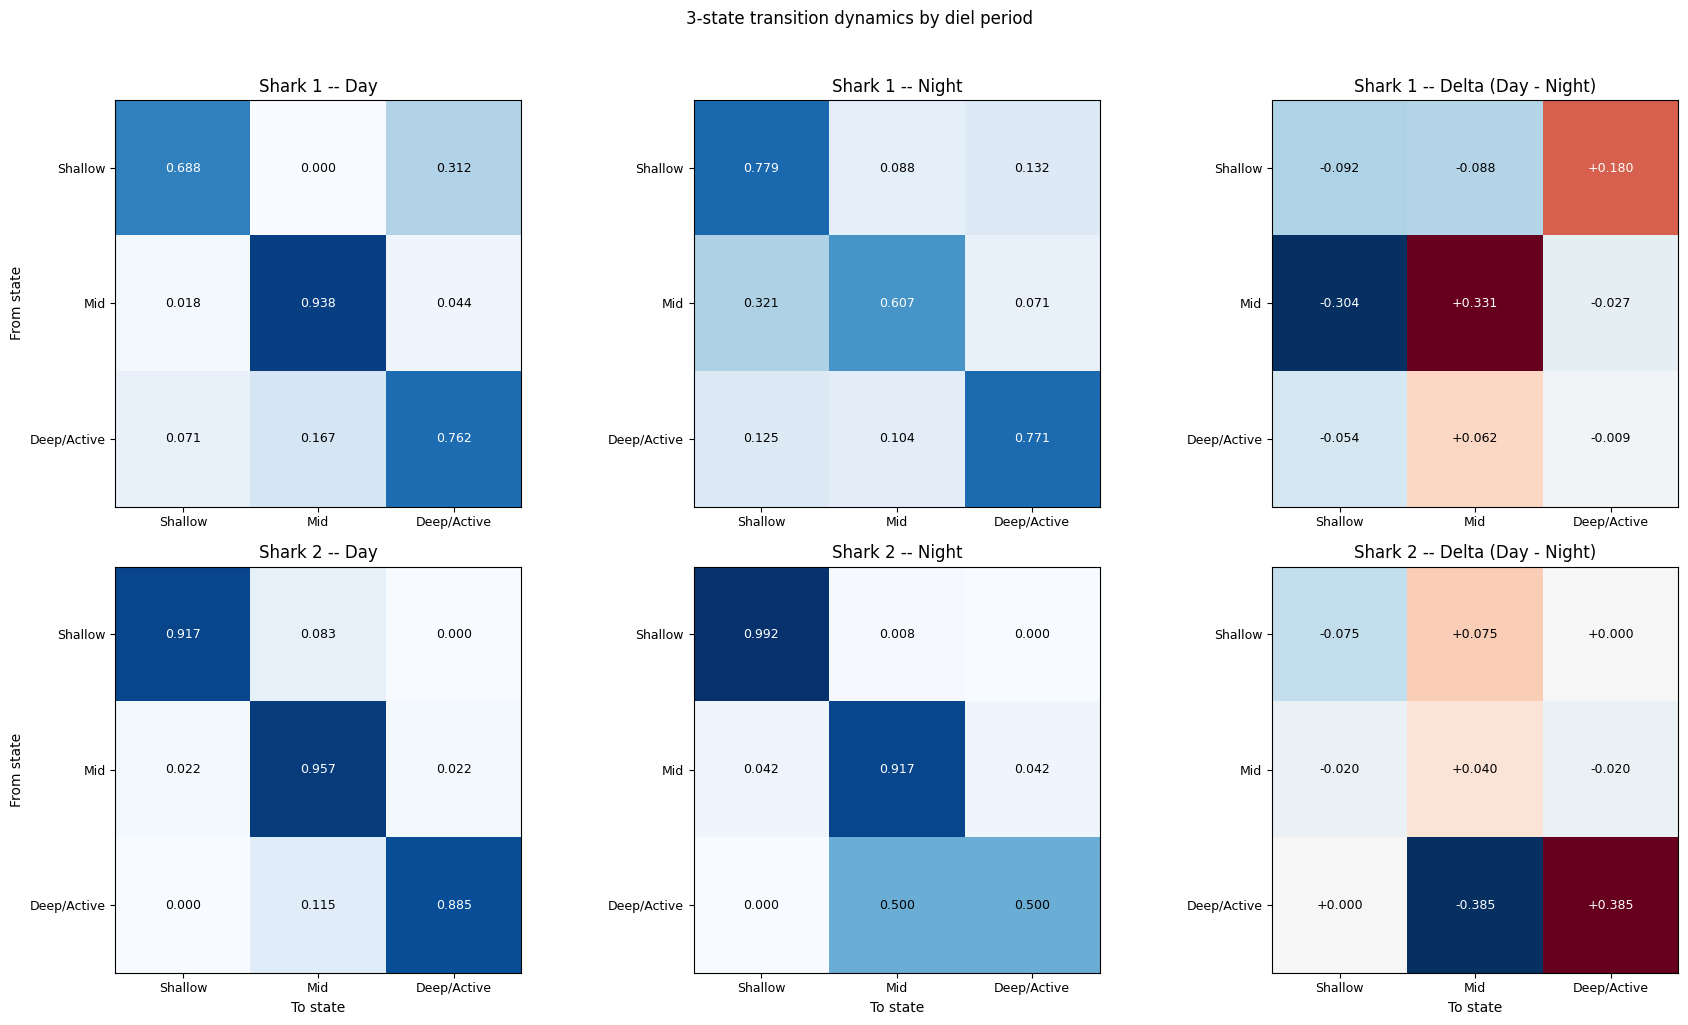

In [33]:
# ============================================================
# 3-state transition heatmaps
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def heatmap3(ax, mat, title, vmin=0, vmax=1, diff=False):
    arr = mat.to_numpy()
    cmap = "RdBu_r" if diff else "Blues"
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
    ax.set_xticks(range(len(mat.columns)))
    ax.set_yticks(range(len(mat.index)))
    ax.set_xticklabels([BIO3_SHORT[c] for c in mat.columns], fontsize=9)
    ax.set_yticklabels([BIO3_SHORT[r] for r in mat.index], fontsize=9)
    ax.set_title(title)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            txt = f"{arr[i, j]:+.3f}" if diff else f"{arr[i, j]:.3f}"
            c = "white" if abs(arr[i, j]) > (0.15 if diff else 0.5) else "black"
            ax.text(j, i, txt, ha="center", va="center", color=c, fontsize=9)
    return im

heatmap3(axes[0, 0], tpm3_sh1_day, "Shark 1 -- Day")
heatmap3(axes[0, 1], tpm3_sh1_night, "Shark 1 -- Night")
heatmap3(axes[0, 2], tpm3_sh1_day - tpm3_sh1_night, "Shark 1 -- Delta (Day - Night)", vmin=-0.3, vmax=0.3, diff=True)

heatmap3(axes[1, 0], tpm3_sh2_day, "Shark 2 -- Day")
heatmap3(axes[1, 1], tpm3_sh2_night, "Shark 2 -- Night")
heatmap3(axes[1, 2], tpm3_sh2_day - tpm3_sh2_night, "Shark 2 -- Delta (Day - Night)", vmin=-0.3, vmax=0.3, diff=True)

for ax in axes[:, 0]:
    ax.set_ylabel("From state")
for ax in axes[-1, :]:
    ax.set_xlabel("To state")

plt.suptitle("3-state transition dynamics by diel period", y=1.02)
plt.tight_layout()
savefig("fig18_3state_transition_dynamics.png")
plt.show()

,shark,window_min,n_windows,mean_points_per_window,sd_mean_depth,sd_log_odba
0,Shark 1,1,1888,1199.259534,23.615788,0.471911
1,Shark 1,5,379,5974.147757,22.795640,0.459887
2,Shark 1,10,190,11916.852632,21.309981,0.455220
3,Shark 1,15,127,17828.362205,19.909713,0.452320
4,Shark 2,1,1810,1199.771271,20.254403,0.516686
5,Shark 2,5,362,5998.856354,20.012474,0.512494
6,Shark 2,10,182,11931.791209,19.782684,0.512103
7,Shark 2,15,122,17799.885246,19.557666,0.512520


[saved figure] revised_hmm_outputs/fig_time_window_comparison.png


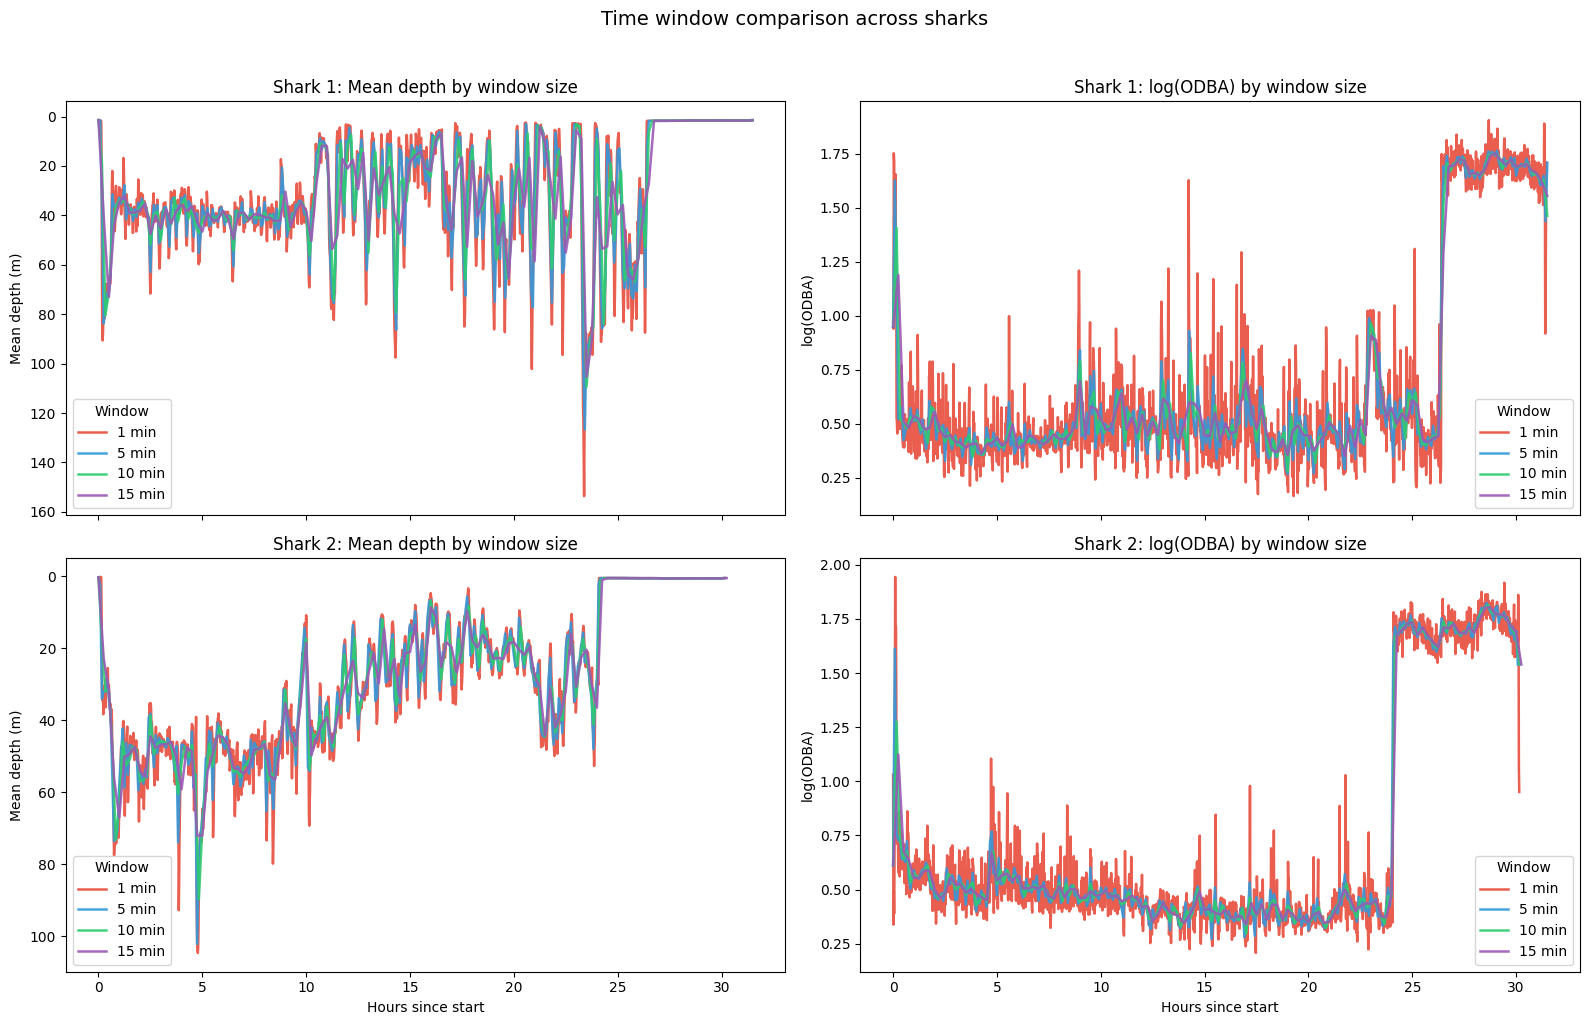

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

window_sizes = [1, 5, 10, 15]
roll_n_local = ROLL_N if "ROLL_N" in globals() else 200

def ensure_odba(df, roll_n=200):
    out = df.copy()
    if "odba" in out.columns:
        return out

    for col in ["acc_x", "acc_y", "acc_z"]:
        out[f"{col}_static"] = out[col].rolling(window=roll_n, center=True, min_periods=1).mean()
        out[f"{col}_dyn"] = out[col] - out[f"{col}_static"]

    out["odba"] = (
        out["acc_x_dyn"].abs()
        + out["acc_y_dyn"].abs()
        + out["acc_z_dyn"].abs()
    )
    return out

def build_window_compare_df(df, shark_name, window_minutes):
    out = df.copy()

    for col in ["depth_m", "depth_temp", "light_1", "light_2", "odba"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=["datetime_local", "depth_m", "odba"]).copy()
    out = out.sort_values("datetime_local").reset_index(drop=True)
    out["time_window"] = out["datetime_local"].dt.floor(f"{window_minutes}min")

    win = (
        out.groupby("time_window", as_index=False)
        .agg(
            mean_depth=("depth_m", "mean"),
            mean_odba=("odba", "mean"),
            mean_temp=("depth_temp", "mean"),
            mean_light_1=("light_1", "mean"),
            n_in_window=("depth_m", "size")
        )
        .sort_values("time_window")
        .reset_index(drop=True)
    )

    win["log_odba"] = np.log1p(win["mean_odba"])
    win["hours_since_start"] = (
        win["time_window"] - win["time_window"].min()
    ).dt.total_seconds() / 3600.0
    win["window_min"] = window_minutes
    win["shark"] = shark_name
    return win

shark1_cmp = ensure_odba(shark1, roll_n_local)
shark2_cmp = ensure_odba(shark2, roll_n_local)

compare_dfs = []
summary_rows = []

for shark_name, raw_df in [("Shark 1", shark1_cmp), ("Shark 2", shark2_cmp)]:
    for w in window_sizes:
        win = build_window_compare_df(raw_df, shark_name, w)
        compare_dfs.append(win)

        summary_rows.append({
            "shark": shark_name,
            "window_min": w,
            "n_windows": len(win),
            "mean_points_per_window": win["n_in_window"].mean(),
            "sd_mean_depth": win["mean_depth"].std(),
            "sd_log_odba": win["log_odba"].std()
        })

compare_df = pd.concat(compare_dfs, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values(["shark", "window_min"]).reset_index(drop=True)

display(summary_df)

colors = {
    1: "#E74C3C",
    5: "#3498DB",
    10: "#2ECC71",
    15: "#9B59B6"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex="col")

for row_idx, shark_name in enumerate(["Shark 1", "Shark 2"]):
    sub = compare_df[compare_df["shark"] == shark_name]

    ax = axes[row_idx, 0]
    for w in window_sizes:
        d = sub[sub["window_min"] == w]
        ax.plot(
            d["hours_since_start"], d["mean_depth"],
            lw=1.8, alpha=0.9, color=colors[w], label=f"{w} min"
        )
    ax.set_title(f"{shark_name}: Mean depth by window size")
    ax.set_ylabel("Mean depth (m)")
    ax.invert_yaxis()
    ax.legend(title="Window")

    ax = axes[row_idx, 1]
    for w in window_sizes:
        d = sub[sub["window_min"] == w]
        ax.plot(
            d["hours_since_start"], d["log_odba"],
            lw=1.8, alpha=0.9, color=colors[w], label=f"{w} min"
        )
    ax.set_title(f"{shark_name}: log(ODBA) by window size")
    ax.set_ylabel("log(ODBA)")
    ax.legend(title="Window")

axes[1, 0].set_xlabel("Hours since start")
axes[1, 1].set_xlabel("Hours since start")

plt.suptitle("Time window comparison across sharks", fontsize=14, y=1.02)
plt.tight_layout()

if "savefig" in globals():
    savefig("fig_time_window_comparison.png")

plt.show()